# Variable Selection Network Meta-Model

This notebook mirrors the modular structure of `random_forest.ipynb`, but replaces the Random Forest with a lightweight **Variable Selection Network (VSN)** for the coursework neural-model family.

The defaults are deliberately small because neural nets take longer to train:

- 2 VSN hyperparameter configurations
- 1 feature-processing method by default
- 5-block CPCV by default, rather than the heavier 10-block / 2-test-block setup

If you have more time, change the quick-run settings in the first configuration cell.


In [1]:
from pathlib import Path
from itertools import combinations
import copy
import json
import math
import random
import re
import time
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
except ImportError as exc:
    raise ImportError(
        "PyTorch is required for this notebook. Install it in your venv with:\n"
        "    pip install torch\n"
        "Then rerun this notebook."
    ) from exc

FEATURE_SELECTION_DIR = Path("../Feature Selection").resolve()
if str(FEATURE_SELECTION_DIR) not in sys.path:
    sys.path.insert(0, str(FEATURE_SELECTION_DIR))

from feature_selection_methods import (
    CorrelationClusterResult,
    CorrelationClusterSelector,
    DEFAULT_EXCLUDE_COLUMNS,
    PCAFeatureReducer,
    PCAFeatureReductionResult,
    infer_numeric_feature_columns,
    run_correlation_cluster_selection,
    run_pca_feature_reduction,
)

print("Feature-selection utilities imported from:", FEATURE_SELECTION_DIR)
print("PyTorch version:", torch.__version__)

RANDOM_STATE = 42


Feature-selection utilities imported from: /Users/akshatg/Desktop/Imperial/Assessments/Term 3/systematic-strategies-with-machine-learning-Cw/03_model_development/Feature Selection
PyTorch version: 2.12.0


In [2]:
# =========================
# 1. Main configuration
# =========================

# Main ticker/model target
TICKER = "cl1s"

# Paths
# This notebook is designed to sit in:
#   03_model_development/Neural Network/
# which is parallel to:
#   03_model_development/Tree/
TRIPLE_BARRIER_DIR = Path("../../data/features/triple_barrier")
FEATURE_SET_PATH = Path(f"../../data/features/clean_feature_set/{TICKER}_clean_feature_set.csv")

# Date settings
DATE_COL = "date"
INSTRUMENT_COL = "instrument"

# Label settings
TARGET_COL = "metalabel"

# Clean local out-of-sample period.
# This should remain untouched during feature selection / CPCV tuning.
TEST_START_DATE = "2022-01-01"
TEST_END_DATE = "2022-06-30"

# For meta-labeling, the cleanest setup is usually to train only where the primary model made a trade.
# The meta-model learns: should we take this +1/-1 signal?
TRAIN_ON_NONZERO_SIGNALS_ONLY = True

# =========================
# Quick-run settings
# =========================
# For submission-day speed:
# - use the first triple-barrier config only
# - use 5 CPCV folds instead of the heavier 10 choose 2 = 45 folds
# - use only one feature-processing setup
#
# To run a more thorough version:
# - set MAX_TB_CONFIGS_TO_RUN = None
# - set CPCV_N_BLOCKS = 10 and CPCV_N_TEST_BLOCKS = 2
# - add more FEATURE_PROCESSING_CONFIGS or VSN_CONFIGS
MAX_TB_CONFIGS_TO_RUN = None
CPCV_N_BLOCKS = 10
CPCV_N_TEST_BLOCKS = 2

# Torch device.
# "auto" will use CUDA if available, then MPS on Apple Silicon, otherwise CPU.
TORCH_DEVICE = "auto"

# Columns that should not be used as model features
NON_FEATURE_COLS = {
    # Identifiers / indexing
    "date",
    "instrument",

    # Target / label columns
    TARGET_COL,
    "target",
    "label",
    "y",
    "meta_label",
    "tb_label",
    "barrier_label",

    # Triple-barrier metadata / leakage-prone columns
    "num_days",
    "t1",
    "vertical_barrier_date",
    "barrier_touch_date",
    "event_end_date",
    "exit_date",
    "exit_price",
    "exit_return",
    "triple_barrier_return",
    "tb_return",
    "realised_return",
    "realized_return",
    "pnl",
    "profit",
    "barrier_touched",
    "first_barrier_touched",
    "hit_barrier",
    "pt",
    "sl",
    "pt_mult",
    "sl_mult",
    "volatility",
    "target_vol",
}


In [3]:
def extract_num_days_from_filename(path: Path) -> int | None:
    """
    Tries to extract num_days from filenames such as:
    cl1s_tb_num_days_10.csv
    triple_barrier_cl1s_10d.csv
    cl1s_pt1_sl1_10.csv
    """
    filename = path.stem.lower()

    patterns = [
        r"num_days[_\-]?(\d+)",
        r"(\d+)d",
        r"horizon[_\-]?(\d+)",
    ]

    for pattern in patterns:
        match = re.search(pattern, filename)
        if match:
            return int(match.group(1))

    return None


def load_feature_set(path: Path, ticker: str) -> pd.DataFrame:
    """
    Loads the clean feature set for a specific ticker.
    """
    if not path.exists():
        raise FileNotFoundError(f"Feature set not found: {path}")

    features = pd.read_csv(path)
    features[DATE_COL] = pd.to_datetime(features[DATE_COL])

    if INSTRUMENT_COL in features.columns:
        features[INSTRUMENT_COL] = features[INSTRUMENT_COL].str.lower()
        features = features[features[INSTRUMENT_COL] == ticker.lower()].copy()

    features = features.sort_values(DATE_COL).reset_index(drop=True)

    return features


def load_triple_barrier_files(
    triple_barrier_dir: Path,
    ticker: str,
    max_configs: int | None = MAX_TB_CONFIGS_TO_RUN,
) -> dict[str, pd.DataFrame]:
    """
    Loads all triple-barrier CSV files for the given ticker.

    IMPORTANT:
    Only keeps merge keys + TARGET_COL.
    This prevents triple-barrier leakage columns from becoming model features.
    """
    if not triple_barrier_dir.exists():
        raise FileNotFoundError(f"Triple-barrier directory not found: {triple_barrier_dir}")

    csv_files = sorted(triple_barrier_dir.glob("*.csv"))

    ticker_files = [
        path for path in csv_files
        if ticker.lower() in path.name.lower()
    ]

    if max_configs is not None:
        ticker_files = ticker_files[:max_configs]

    if len(ticker_files) == 0:
        raise FileNotFoundError(
            f"No triple-barrier CSV files found for ticker '{ticker}' in {triple_barrier_dir}"
        )

    tb_data = {}

    for path in ticker_files:
        df = pd.read_csv(path)
        df[DATE_COL] = pd.to_datetime(df[DATE_COL])

        if INSTRUMENT_COL in df.columns:
            df[INSTRUMENT_COL] = df[INSTRUMENT_COL].str.lower()
            df = df[df[INSTRUMENT_COL] == ticker.lower()].copy()

        # Get num_days only as metadata for CPCV embargo, not as a model column.
        if "num_days" in df.columns:
            num_days = int(pd.to_numeric(df["num_days"], errors="coerce").dropna().mode().iloc[0])
        else:
            num_days = extract_num_days_from_filename(path)

        # Find the label column.
        possible_label_cols = [TARGET_COL, "y"]
        label_col = next((col for col in possible_label_cols if col in df.columns), None)

        if label_col is None:
            raise ValueError(
                f"No metalabel/target column found in {path.name}. "
                f"Available columns: {list(df.columns)}"
            )

        # Keep ONLY merge keys + label.
        keep_cols = [DATE_COL]

        if INSTRUMENT_COL in df.columns:
            keep_cols.append(INSTRUMENT_COL)

        keep_cols.append(label_col)

        df = df[keep_cols].copy()

        # Standardise label name back to TARGET_COL, e.g. "metalabel".
        if label_col != TARGET_COL:
            df = df.rename(columns={label_col: TARGET_COL})

        df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

        df = df.sort_values(DATE_COL).reset_index(drop=True)

        # Store num_days as dataframe metadata, not as a column.
        df.attrs["num_days"] = num_days

        tb_data[path.stem] = df

    return tb_data

In [4]:
features = load_feature_set(FEATURE_SET_PATH, TICKER)
tb_configs = load_triple_barrier_files(TRIPLE_BARRIER_DIR, TICKER, max_configs=MAX_TB_CONFIGS_TO_RUN)

print(f"Loaded feature set for {TICKER}: {features.shape}")
print(f"Loaded {len(tb_configs)} triple-barrier configurations:")

for config_name, tb_df in tb_configs.items():
    print(
        f"  {config_name}: shape={tb_df.shape}, "
        f"columns={list(tb_df.columns)}, "
        f"num_days={tb_df.attrs.get('num_days')}, "
        f"target_counts={tb_df[TARGET_COL].value_counts(dropna=False).to_dict()}"
    )

display(features.head())

first_config_name = list(tb_configs.keys())[0]
display(tb_configs[first_config_name].head())

Loaded feature set for cl1s: (626, 146)
Loaded 6 triple-barrier configurations:
  cl1s_ewma_10d_tp1_5_sl1_5: shape=(412, 3), columns=['date', 'instrument', 'metalabel'], num_days=10, target_counts={1: 284, 0: 128}
  cl1s_ewma_10d_tp2_sl2: shape=(412, 3), columns=['date', 'instrument', 'metalabel'], num_days=10, target_counts={1: 285, 0: 127}
  cl1s_ewma_5d_tp2_sl2: shape=(417, 3), columns=['date', 'instrument', 'metalabel'], num_days=5, target_counts={1: 272, 0: 145}
  cl1s_garman_klass_10d_tp2_sl2: shape=(412, 3), columns=['date', 'instrument', 'metalabel'], num_days=10, target_counts={1: 281, 0: 131}
  cl1s_parkinson_10d_tp2_sl2: shape=(412, 3), columns=['date', 'instrument', 'metalabel'], num_days=10, target_counts={1: 281, 0: 131}
  cl1s_rolling_10d_tp2_sl2: shape=(412, 3), columns=['date', 'instrument', 'metalabel'], num_days=10, target_counts={1: 283, 0: 129}


,date,instrument,primary_signal,open,high,low,close,volume,open_interest,ret_1d,...,hmm_market_stress,hmm_market_upside_breakout,hmm_market_calm_positive,hmm_market_calm_negative,signal_x_hmm_confidence,ret_5d_x_hmm_confidence,vol_20d_x_hmm_confidence,signal_x_hmm_prob_stress,signal_x_hmm_prob_high_or_extreme_vol,signal_x_hmm_prob_positive_or_strong_upside
0,2020-01-03,cl1s,0,24.795579,25.974970,24.775315,25.553469,2.185752e+06,958523.501762,0.030566,...,0.0,1.0,0.0,0.0,0.000000,0.022015,0.009606,0.000000,0.000000,0.000000
1,2020-01-06,cl1s,0,25.820960,26.230302,25.387301,25.642633,1.786962e+06,909240.146872,0.003489,...,0.0,0.0,0.0,1.0,0.000000,0.024615,0.009457,0.000000,0.000000,0.000000
2,2020-01-07,cl1s,-1,25.496729,25.593998,25.172498,25.411618,1.437614e+06,877280.234192,-0.009009,...,0.0,0.0,0.0,1.0,-0.999224,0.016524,0.009817,-0.000372,-0.000423,-0.000404
3,2020-01-08,cl1s,0,25.468359,26.607221,23.972842,24.159275,2.974939e+06,792303.827743,-0.049282,...,1.0,0.0,0.0,0.0,0.000000,-0.023747,0.015258,0.000000,0.000000,0.000000
4,2020-01-09,cl1s,0,24.313285,24.442978,23.774251,24.139011,1.852834e+06,695693.746602,-0.000839,...,0.0,0.0,0.0,1.0,0.000000,-0.025944,0.014936,0.000000,0.000000,0.000000


,date,instrument,metalabel
0,2020-01-07,cl1s,1
1,2020-01-22,cl1s,1
2,2020-01-23,cl1s,1
3,2020-01-24,cl1s,1
4,2020-01-27,cl1s,1


In [5]:

def get_feature_cols(df: pd.DataFrame, non_feature_cols: set[str]) -> list[str]:
    """
    Selects model feature columns from the merged dataframe.
    Keeps primary_signal as a feature unless it is explicitly in NON_FEATURE_COLS.
    """
    feature_cols = [
        col for col in df.columns
        if col not in non_feature_cols
    ]

    # Keep only numeric columns because sklearn models need numeric X.
    numeric_feature_cols = [
        col for col in feature_cols
        if pd.api.types.is_numeric_dtype(df[col])
    ]

    dropped_non_numeric = sorted(set(feature_cols) - set(numeric_feature_cols))
    if dropped_non_numeric:
        print(f"Dropped non-numeric feature columns: {dropped_non_numeric}")

    return numeric_feature_cols


def merge_features_with_tb(
    features_df: pd.DataFrame,
    tb_df: pd.DataFrame,
    ticker: str,
    target_col: str = TARGET_COL,
) -> pd.DataFrame:
    """
    Merges the clean feature set with one triple-barrier config.

    Expected:
        features_df has date, instrument, features
        tb_df has date, instrument, metalabel, num_days, etc.

    Output:
        one merged dataframe with features + target + triple-barrier metadata.
    """
    features_clean = features_df.copy()
    tb_clean = tb_df.copy()

    features_clean[DATE_COL] = pd.to_datetime(features_clean[DATE_COL])
    tb_clean[DATE_COL] = pd.to_datetime(tb_clean[DATE_COL])

    if INSTRUMENT_COL in features_clean.columns:
        features_clean[INSTRUMENT_COL] = features_clean[INSTRUMENT_COL].str.lower()
        features_clean = features_clean[features_clean[INSTRUMENT_COL] == ticker.lower()].copy()

    if INSTRUMENT_COL in tb_clean.columns:
        tb_clean[INSTRUMENT_COL] = tb_clean[INSTRUMENT_COL].str.lower()
        tb_clean = tb_clean[tb_clean[INSTRUMENT_COL] == ticker.lower()].copy()

    # If earlier loading renamed metalabel to target, rename it back/check cleanly here.
    if "target" in tb_clean.columns and target_col not in tb_clean.columns:
        tb_clean = tb_clean.rename(columns={"target": target_col})

    if target_col not in tb_clean.columns:
        raise ValueError(
            f"Target column '{target_col}' not found in triple-barrier dataframe. "
            f"Available columns: {list(tb_clean.columns)}"
        )

    merge_keys = [DATE_COL]
    if INSTRUMENT_COL in features_clean.columns and INSTRUMENT_COL in tb_clean.columns:
        merge_keys.append(INSTRUMENT_COL)

    merged = features_clean.merge(
        tb_clean,
        on=merge_keys,
        how="inner",
        suffixes=("", "_tb"),
    )

    merged = merged.sort_values(DATE_COL).reset_index(drop=True)

    return merged


def clean_model_dataframe(
    merged_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = TARGET_COL,
    train_on_nonzero_signals_only: bool = TRAIN_ON_NONZERO_SIGNALS_ONLY,
) -> pd.DataFrame:
    """
    Cleans the merged dataframe before splitting:
    - optionally removes primary_signal == 0 rows
    - removes rows with missing target
    - replaces inf with NaN
    - drops rows with missing X or y
    """
    df = merged_df.copy()

    if train_on_nonzero_signals_only and "primary_signal" in df.columns:
        df = df[df["primary_signal"] != 0].copy()

    df = df.replace([np.inf, -np.inf], np.nan)

    required_cols = feature_cols + [target_col, DATE_COL]
    df = df.dropna(subset=required_cols).copy()

    # Make sure target is integer binary 0/1
    df[target_col] = df[target_col].astype(int)

    invalid_targets = sorted(set(df[target_col].unique()) - {0, 1})
    if invalid_targets:
        raise ValueError(
            f"Target column '{target_col}' must be binary 0/1. "
            f"Found invalid values: {invalid_targets}"
        )

    df = df.sort_values(DATE_COL).reset_index(drop=True)

    return df


def chronological_train_test_split(
    df: pd.DataFrame,
    test_start_date: str = TEST_START_DATE,
    test_end_date: str = TEST_END_DATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Chronological train/test split.

    Train:
        date < TEST_START_DATE

    Test:
        TEST_START_DATE <= date <= TEST_END_DATE
    """
    test_start_date = pd.to_datetime(test_start_date)
    test_end_date = pd.to_datetime(test_end_date)

    train_df = df[df[DATE_COL] < test_start_date].copy()

    test_df = df[
        (df[DATE_COL] >= test_start_date)
        & (df[DATE_COL] <= test_end_date)
    ].copy()

    return train_df, test_df


def build_xy(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = TARGET_COL,
):
    """
    Builds X/y arrays for sklearn.
    """
    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    return X_train, y_train, X_test, y_test

In [6]:
# =========================
# 6. Build model datasets for every triple-barrier config
# =========================

datasets_by_config = {}

for config_name, tb_df in tb_configs.items():
    print("=" * 80)
    print(f"Building dataset for triple-barrier config: {config_name}")

    merged_df = merge_features_with_tb(
        features_df=features,
        tb_df=tb_df,
        ticker=TICKER,
        target_col=TARGET_COL,
    )

    feature_cols = get_feature_cols(
        df=merged_df,
        non_feature_cols=NON_FEATURE_COLS,
    )

    model_df = clean_model_dataframe(
        merged_df=merged_df,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        train_on_nonzero_signals_only=TRAIN_ON_NONZERO_SIGNALS_ONLY,
    )

    train_df, test_df = chronological_train_test_split(
        df=model_df,
        test_start_date=TEST_START_DATE,
        test_end_date=TEST_END_DATE,
    )

    X_train, y_train, X_test, y_test = build_xy(
        train_df=train_df,
        test_df=test_df,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
    )

    datasets_by_config[config_name] = {
        "merged_df": merged_df,
        "model_df": model_df,
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "feature_cols": feature_cols,
        "num_days": tb_df.attrs.get("num_days"),
    }

    print(f"Merged shape:     {merged_df.shape}")
    print(f"Model shape:      {model_df.shape}")
    print(f"Train shape:      {train_df.shape}")
    print(f"Test shape:       {test_df.shape}")
    print(f"X_train shape:    {X_train.shape}")
    print(f"X_test shape:     {X_test.shape}")
    print(f"Num features:     {len(feature_cols)}")
    print(f"Train target dist:{y_train.value_counts(normalize=True).round(3).to_dict()}")
    print(f"Test target dist: {y_test.value_counts(normalize=True).round(3).to_dict()}")
    print(f"num_days:         {datasets_by_config[config_name]['num_days']}")

Building dataset for triple-barrier config: cl1s_ewma_10d_tp1_5_sl1_5
Merged shape:     (411, 147)
Model shape:      (411, 147)
Train shape:      (333, 147)
Test shape:       (78, 147)
X_train shape:    (333, 144)
X_test shape:     (78, 144)
Num features:     144
Train target dist:{1: 0.661, 0: 0.339}
Test target dist: {1: 0.821, 0: 0.179}
num_days:         10
Building dataset for triple-barrier config: cl1s_ewma_10d_tp2_sl2
Merged shape:     (411, 147)
Model shape:      (411, 147)
Train shape:      (333, 147)
Test shape:       (78, 147)
X_train shape:    (333, 144)
X_test shape:     (78, 144)
Num features:     144
Train target dist:{1: 0.664, 0: 0.336}
Test target dist: {1: 0.821, 0: 0.179}
num_days:         10
Building dataset for triple-barrier config: cl1s_ewma_5d_tp2_sl2
Merged shape:     (416, 147)
Model shape:      (416, 147)
Train shape:      (333, 147)
Test shape:       (83, 147)
X_train shape:    (333, 144)
X_test shape:     (83, 144)
Num features:     144
Train target dist:{

In [7]:
# =========================
# 7. Sanity check one config
# =========================

first_config_name = list(datasets_by_config.keys())[0]
data = datasets_by_config[first_config_name]

print(f"Using config: {first_config_name}")

display(data["train_df"].head())
display(data["test_df"].head())

print("Feature columns:")
print(data["feature_cols"])

print("\nTrain date range:")
print(data["train_df"][DATE_COL].min(), "to", data["train_df"][DATE_COL].max())

print("\nTest date range:")
print(data["test_df"][DATE_COL].min(), "to", data["test_df"][DATE_COL].max())

print("\nAny NaNs in X_train?")
print(data["X_train"].isna().sum().sort_values(ascending=False).head(10))

print("\nAny NaNs in X_test?")
print(data["X_test"].isna().sum().sort_values(ascending=False).head(10))

Using config: cl1s_ewma_10d_tp1_5_sl1_5


,date,instrument,primary_signal,open,high,low,close,volume,open_interest,ret_1d,...,hmm_market_upside_breakout,hmm_market_calm_positive,hmm_market_calm_negative,signal_x_hmm_confidence,ret_5d_x_hmm_confidence,vol_20d_x_hmm_confidence,signal_x_hmm_prob_stress,signal_x_hmm_prob_high_or_extreme_vol,signal_x_hmm_prob_positive_or_strong_upside,metalabel
0,2020-01-07,cl1s,-1,25.496729,25.593998,25.172498,25.411618,1.437614e+06,8.772802e+05,-0.009009,...,0.0,0.0,1.0,-0.999224,0.016524,0.009817,-0.000372,-0.000423,-0.000404,1
1,2020-01-22,cl1s,-1,23.599977,23.648586,22.696648,22.984255,1.530855e+06,1.194576e+06,-0.028092,...,0.0,0.0,0.0,-0.957739,-0.024987,0.015385,-0.957739,-0.957819,-0.007740,1
2,2020-01-23,cl1s,-1,22.729054,22.793867,22.186246,22.518412,1.737915e+06,1.183091e+06,-0.020268,...,0.0,0.0,1.0,-0.928603,-0.036123,0.015298,-0.067596,-0.068314,-0.003801,1
3,2020-01-24,cl1s,-1,22.558920,22.664241,21.813573,21.951300,1.447108e+06,1.203433e+06,-0.025184,...,0.0,0.0,0.0,-0.876178,-0.064969,0.014697,-0.876178,-0.876294,-0.011184,1
4,2020-01-27,cl1s,-1,21.752811,21.756861,21.116834,21.525966,1.759849e+06,1.191300e+06,-0.019376,...,0.0,0.0,1.0,-0.902392,-0.083800,0.015008,-0.092819,-0.093687,-0.004789,1


,date,instrument,primary_signal,open,high,low,close,volume,open_interest,ret_1d,...,hmm_market_upside_breakout,hmm_market_calm_positive,hmm_market_calm_negative,signal_x_hmm_confidence,ret_5d_x_hmm_confidence,vol_20d_x_hmm_confidence,signal_x_hmm_prob_stress,signal_x_hmm_prob_high_or_extreme_vol,signal_x_hmm_prob_positive_or_strong_upside,metalabel
333,2022-01-03,cl1s,1,22.564638,22.794190,22.141309,22.680904,1.065440e+06,918132.919438,0.011568,...,0.0,0.0,1.0,0.992867,0.006701,0.020927,0.000478,0.005906,0.006656,1
334,2022-01-04,cl1s,1,22.663017,23.145970,22.567619,22.952193,1.250668e+06,902998.030950,0.011961,...,0.0,0.0,1.0,0.995873,0.013238,0.018668,0.000086,0.003566,0.004041,1
335,2022-01-05,cl1s,1,23.008836,23.426202,22.809096,23.208575,1.334695e+06,882194.268008,0.011170,...,0.0,0.0,1.0,0.997911,0.016814,0.017271,0.000088,0.001718,0.002001,1
336,2022-01-06,cl1s,1,23.026723,23.921080,22.874682,23.688547,1.598908e+06,863986.782478,0.020681,...,1.0,0.0,0.0,0.965307,0.030969,0.017083,0.000831,0.966138,0.970264,1
337,2022-01-07,cl1s,1,23.736246,23.989648,23.408315,23.521600,1.390162e+06,801562.076196,-0.007048,...,0.0,0.0,1.0,0.991919,0.048666,0.016848,0.006554,0.007040,0.001528,1


Feature columns:
['primary_signal', 'open', 'high', 'low', 'close', 'volume', 'open_interest', 'ret_1d', 'ret_5d', 'ret_20d', 'ret_63d', 'ret_126d', 'ret_252d', 'mom_sign_5d', 'mom_sign_20d', 'mom_sign_63d', 'mom_sign_126d', 'mom_sign_252d', 'ret_spread_5_20', 'ret_spread_20_63', 'price_vs_sma5', 'price_vs_sma10', 'price_vs_sma20', 'price_vs_sma50', 'price_vs_sma100', 'price_vs_sma200', 'price_vs_ema5', 'price_vs_ema10', 'price_vs_ema20', 'price_vs_ema50', 'sma5_vs_sma20', 'sma10_vs_sma50', 'sma20_vs_sma50', 'sma50_vs_sma100', 'sma50_vs_sma200', 'sma100_vs_sma200', 'ema5_vs_ema20', 'ema12_vs_ema26', 'ema20_vs_ema50', 'ema20_vs_ema100', 'sma20_slope', 'sma50_slope', 'sma100_slope', 'ema20_slope', 'ema50_slope', 'macd_line', 'macd_signal', 'macd_hist', 'macd_hist_chg', 'macd_zscore', 'vol_5d', 'vol_10d', 'vol_20d', 'vol_63d', 'vol_126d', 'vol_252d', 'ewma_vol_5d', 'ewma_vol_10d', 'ewma_vol_20d', 'ewma_vol_63d', 'vol_ratio_5_20d', 'vol_ratio_20_63d', 'vol_ratio_63_126d', 'park_vol_5d', 'p

In [8]:
# =========================
# 7. VSN hyperparameter configs + feature processing configs
# =========================

PROTECTED_FEATURES = [
    "primary_signal",
]

# Keep this short for speed. This still counts as neural-net hyperparameter tuning.
VSN_CONFIGS = [
    {
        "model_name": "vsn_small_fast",
        "model_params": {
            "hidden_dim": 16,
            "selector_hidden_dim": 16,
            "dropout": 0.15,
            "lr": 1e-3,
            "weight_decay": 1e-4,
            "batch_size": 64,
            "max_epochs": 60,
            "patience": 8,
            "val_fraction": 0.15,
            "use_pos_weight": True,
            "device": TORCH_DEVICE,
            "random_state": RANDOM_STATE,
            "verbose": False,
        },
    },
    {
        "model_name": "vsn_medium_regularised",
        "model_params": {
            "hidden_dim": 32,
            "selector_hidden_dim": 32,
            "dropout": 0.25,
            "lr": 8e-4,
            "weight_decay": 5e-4,
            "batch_size": 64,
            "max_epochs": 80,
            "patience": 10,
            "val_fraction": 0.15,
            "use_pos_weight": True,
            "device": TORCH_DEVICE,
            "random_state": RANDOM_STATE,
            "verbose": False,
        },
    },
]

# Keep this to one feature-processing method by default for speed.
# Add the PCA config back if you have time.
FEATURE_PROCESSING_CONFIGS = [
    {
        "feature_method": "corr_cluster",
        "feature_params": {
            "corr_threshold": 0.90,
            "corr_method": "spearman",
            "selection_method": "target_corr",
            "min_periods": 20,
        },
    },
    {
        "feature_method": "pca",
        "feature_params": {
            "n_components": 0.95,
            "standardize": True,
            "impute_strategy": "median",
            "component_prefix": "pca",
            "random_state": RANDOM_STATE,
            "svd_solver": "full",
        },
    },
]


In [9]:
# =========================
# 8. Variable Selection Network implementation
# =========================

def set_global_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_torch_device(device: str = "auto") -> torch.device:
    if device != "auto":
        return torch.device(device)

    if torch.cuda.is_available():
        return torch.device("cuda")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


class TabularVSN(nn.Module):
    """
    Lightweight Variable Selection Network for tabular meta-label classification.

    For each observation:
    1. A selector network creates a softmax gate over input variables.
    2. Each variable is embedded into hidden_dim.
    3. The gated variable embeddings are pooled.
    4. A small prediction head outputs a binary logit.
    """
    def __init__(
        self,
        n_features: int,
        hidden_dim: int = 16,
        selector_hidden_dim: int = 16,
        dropout: float = 0.15,
    ):
        super().__init__()

        self.n_features = n_features
        self.hidden_dim = hidden_dim

        self.selector = nn.Sequential(
            nn.Linear(n_features, selector_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(selector_hidden_dim, n_features),
        )

        # Scalar feature j -> hidden vector using feature-specific parameters.
        self.feature_weight = nn.Parameter(torch.empty(n_features, hidden_dim))
        self.feature_bias = nn.Parameter(torch.zeros(n_features, hidden_dim))

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

        nn.init.xavier_uniform_(self.feature_weight)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        gate_logits = self.selector(x)
        gates = torch.softmax(gate_logits, dim=1)

        # Shape:
        # x:        [batch, n_features]
        # embedded: [batch, n_features, hidden_dim]
        embedded = x.unsqueeze(-1) * self.feature_weight.unsqueeze(0) + self.feature_bias.unsqueeze(0)

        selected_context = torch.sum(gates.unsqueeze(-1) * embedded, dim=1)

        logit = self.head(selected_context).squeeze(-1)

        return logit, gates


class TorchVSNClassifier(BaseEstimator, ClassifierMixin):
    """
    sklearn-style wrapper around TabularVSN.

    It includes:
    - StandardScaler fit only on training data
    - chronological validation split inside each training fold
    - BCEWithLogitsLoss with optional positive-class weighting
    - early stopping on validation loss
    """
    def __init__(
        self,
        hidden_dim: int = 16,
        selector_hidden_dim: int = 16,
        dropout: float = 0.15,
        lr: float = 1e-3,
        weight_decay: float = 1e-4,
        batch_size: int = 64,
        max_epochs: int = 60,
        patience: int = 8,
        val_fraction: float = 0.15,
        use_pos_weight: bool = True,
        device: str = "auto",
        random_state: int = RANDOM_STATE,
        verbose: bool = False,
    ):
        self.hidden_dim = hidden_dim
        self.selector_hidden_dim = selector_hidden_dim
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.val_fraction = val_fraction
        self.use_pos_weight = use_pos_weight
        self.device = device
        self.random_state = random_state
        self.verbose = verbose

    def _prepare_arrays(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            X_arr = X.to_numpy(dtype=np.float32)
        else:
            X_arr = np.asarray(X, dtype=np.float32)

        if y is None:
            return X_arr

        y_arr = np.asarray(y, dtype=np.float32).reshape(-1)

        return X_arr, y_arr

    def _make_loader(self, X_arr, y_arr, shuffle: bool):
        X_tensor = torch.tensor(X_arr, dtype=torch.float32)
        y_tensor = torch.tensor(y_arr, dtype=torch.float32)

        dataset = TensorDataset(X_tensor, y_tensor)

        generator = torch.Generator()
        generator.manual_seed(self.random_state)

        return DataLoader(
            dataset,
            batch_size=min(self.batch_size, len(dataset)),
            shuffle=shuffle,
            generator=generator if shuffle else None,
        )

    def fit(self, X, y):
        set_global_seed(self.random_state)

        X_arr, y_arr = self._prepare_arrays(X, y)

        if X_arr.ndim != 2:
            raise ValueError(f"Expected X to be 2D, got shape {X_arr.shape}")

        unique_classes = np.unique(y_arr.astype(int))
        if len(unique_classes) < 2:
            raise ValueError(f"VSN needs both classes in training data. Got classes: {unique_classes}")

        self.classes_ = np.array([0, 1])
        self.feature_names_in_ = list(X.columns) if isinstance(X, pd.DataFrame) else [f"x{i}" for i in range(X_arr.shape[1])]
        self.n_features_in_ = X_arr.shape[1]

        # Fit scaler on training data only.
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X_arr).astype(np.float32)

        # Chronological train/validation split.
        n = len(X_scaled)
        n_val = max(1, int(math.ceil(n * self.val_fraction)))
        n_val = min(n_val, max(1, n - 2))

        train_end = n - n_val

        X_train = X_scaled[:train_end]
        y_train = y_arr[:train_end]
        X_val = X_scaled[train_end:]
        y_val = y_arr[train_end:]

        train_loader = self._make_loader(X_train, y_train, shuffle=True)

        device = resolve_torch_device(self.device)
        self.device_ = device

        self.model_ = TabularVSN(
            n_features=self.n_features_in_,
            hidden_dim=self.hidden_dim,
            selector_hidden_dim=self.selector_hidden_dim,
            dropout=self.dropout,
        ).to(device)

        if self.use_pos_weight:
            n_pos = float(np.sum(y_train == 1))
            n_neg = float(np.sum(y_train == 0))
            pos_weight_value = n_neg / max(n_pos, 1.0) if n_pos > 0 else 1.0
        else:
            pos_weight_value = 1.0

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
        )

        optimizer = torch.optim.AdamW(
            self.model_.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay,
        )

        X_val_tensor = torch.tensor(X_val, dtype=torch.float32, device=device)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32, device=device)

        best_val_loss = np.inf
        best_state = None
        epochs_without_improvement = 0

        history_rows = []

        for epoch in range(1, self.max_epochs + 1):
            self.model_.train()
            train_losses = []

            for xb, yb in train_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer.zero_grad()
                logits, _ = self.model_(xb)
                loss = criterion(logits, yb)
                loss.backward()

                nn.utils.clip_grad_norm_(self.model_.parameters(), max_norm=1.0)

                optimizer.step()
                train_losses.append(float(loss.detach().cpu().item()))

            self.model_.eval()
            with torch.no_grad():
                val_logits, _ = self.model_(X_val_tensor)
                val_loss = float(criterion(val_logits, y_val_tensor).detach().cpu().item())

            mean_train_loss = float(np.mean(train_losses)) if train_losses else np.nan

            history_rows.append(
                {
                    "epoch": epoch,
                    "train_loss": mean_train_loss,
                    "val_loss": val_loss,
                }
            )

            if self.verbose and (epoch == 1 or epoch % 10 == 0):
                print(f"epoch={epoch:03d} train_loss={mean_train_loss:.5f} val_loss={val_loss:.5f}")

            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_state = copy.deepcopy(self.model_.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.training_history_ = pd.DataFrame(history_rows)
        self.best_val_loss_ = float(best_val_loss)
        self.n_epochs_ = len(history_rows)

        self.feature_importances_ = self.get_mean_selection_weights(X)

        return self

    def predict_proba(self, X):
        if not hasattr(self, "model_"):
            raise ValueError("Model has not been fitted yet.")

        X_arr = self._prepare_arrays(X)
        X_scaled = self.scaler_.transform(X_arr).astype(np.float32)

        device = self.device_
        self.model_.eval()

        probs = []
        batch_size = max(1, self.batch_size)

        with torch.no_grad():
            for start in range(0, len(X_scaled), batch_size):
                xb = torch.tensor(X_scaled[start:start + batch_size], dtype=torch.float32, device=device)
                logits, _ = self.model_(xb)
                p1 = torch.sigmoid(logits).detach().cpu().numpy()
                probs.append(p1)

        p1 = np.concatenate(probs) if probs else np.array([], dtype=float)
        p0 = 1.0 - p1

        return np.column_stack([p0, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def get_mean_selection_weights(self, X) -> np.ndarray:
        """
        Mean VSN gate weight for each feature.
        Useful as native VSN variable importance.
        """
        if not hasattr(self, "model_"):
            raise ValueError("Model has not been fitted yet.")

        X_arr = self._prepare_arrays(X)
        X_scaled = self.scaler_.transform(X_arr).astype(np.float32)

        device = self.device_
        self.model_.eval()

        gates_all = []
        batch_size = max(1, self.batch_size)

        with torch.no_grad():
            for start in range(0, len(X_scaled), batch_size):
                xb = torch.tensor(X_scaled[start:start + batch_size], dtype=torch.float32, device=device)
                _, gates = self.model_(xb)
                gates_all.append(gates.detach().cpu().numpy())

        gates = np.vstack(gates_all) if gates_all else np.empty((0, self.n_features_in_))

        return gates.mean(axis=0)


def make_vsn_classifier(model_params: dict) -> TorchVSNClassifier:
    """
    Creates a VSN classifier from a parameter dictionary.
    """
    return TorchVSNClassifier(**model_params)


In [10]:
# CPCV_N_BLOCKS and CPCV_N_TEST_BLOCKS are set in the main configuration cell.


def make_time_blocks(n_samples: int, n_blocks: int) -> list[np.ndarray]:
    """
    Splits row positions into chronological blocks.
    """
    indices = np.arange(n_samples)
    blocks = np.array_split(indices, n_blocks)
    return [block for block in blocks if len(block) > 0]


def get_label_end_series(
    df: pd.DataFrame,
    fallback_num_days: int | None = None,
) -> pd.Series:
    """
    Returns the label end date for purging.

    Prefer timeout_date because it is the maximum possible information horizon.
    This is conservative and directly linked to num_days.
    """
    if "timeout_date" in df.columns:
        return pd.to_datetime(df["timeout_date"])

    if "touch_date" in df.columns:
        return pd.to_datetime(df["touch_date"])

    if fallback_num_days is None:
        raise ValueError(
            "No timeout_date/touch_date found and fallback_num_days was not provided."
        )

    return pd.to_datetime(df[DATE_COL]) + pd.Timedelta(days=fallback_num_days)


def generate_cpcv_splits(
    train_df: pd.DataFrame,
    n_blocks: int = CPCV_N_BLOCKS,
    n_test_blocks: int = CPCV_N_TEST_BLOCKS,
    embargo_size: int | None = None,
    date_col: str = DATE_COL,
):
    """
    Generates CPCV train/test index splits with purging and embargo.

    Purging:
        Remove training samples whose label interval overlaps the test interval.

    Embargo:
        Remove the next embargo_size rows after each test block.
        For this coursework, embargo_size should usually be num_days.
    """
    df = train_df.sort_values(date_col).reset_index(drop=True).copy()

    n_samples = len(df)

    if n_samples < n_blocks:
        raise ValueError(
            f"Not enough samples for CPCV: n_samples={n_samples}, n_blocks={n_blocks}"
        )

    if embargo_size is None:
        if "num_days" in df.columns:
            embargo_size = int(df["num_days"].mode().iloc[0])
        else:
            embargo_size = 0

    blocks = make_time_blocks(n_samples=n_samples, n_blocks=n_blocks)

    event_start = pd.to_datetime(df[date_col]).reset_index(drop=True)
    event_end = get_label_end_series(df, fallback_num_days=embargo_size).reset_index(drop=True)

    split_id = 0

    for test_block_ids in combinations(range(len(blocks)), n_test_blocks):
        split_id += 1

        test_idx = np.concatenate([blocks[block_id] for block_id in test_block_ids])
        test_idx = np.sort(test_idx)

        test_mask = np.zeros(n_samples, dtype=bool)
        test_mask[test_idx] = True

        train_mask = ~test_mask

        # Purge and embargo around each selected test block separately
        for block_id in test_block_ids:
            block_idx = blocks[block_id]

            test_block_start = event_start.iloc[block_idx].min()
            test_block_end = event_end.iloc[block_idx].max()

            # Purge train rows whose label interval overlaps this test block interval
            overlap_mask = (
                (event_start <= test_block_end)
                & (event_end >= test_block_start)
            ).to_numpy()

            train_mask[overlap_mask] = False

            # Embargo rows immediately after the test block
            block_last_pos = int(block_idx.max())
            embargo_start_pos = block_last_pos + 1
            embargo_end_pos = min(block_last_pos + embargo_size, n_samples - 1)

            if embargo_start_pos <= embargo_end_pos:
                embargo_idx = np.arange(embargo_start_pos, embargo_end_pos + 1)
                train_mask[embargo_idx] = False

        train_idx = np.where(train_mask)[0]

        yield {
            "split_id": split_id,
            "test_block_ids": test_block_ids,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "embargo_size": embargo_size,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
        }

In [11]:
# =========================
# 10. Metrics helpers
# =========================

def get_positive_class_proba(model, X: pd.DataFrame) -> np.ndarray:
    """
    Returns P(y=1) from a fitted sklearn classifier.
    """
    proba = model.predict_proba(X)

    classes = list(model.classes_)

    if 1 not in classes:
        raise ValueError(f"Model was not trained with positive class 1. Classes: {classes}")

    positive_class_index = classes.index(1)

    return proba[:, positive_class_index]


def classification_metrics(
    y_true: pd.Series,
    y_proba: np.ndarray,
    threshold: float = 0.5,
) -> dict:
    """
    Computes classification metrics for one fold.
    """
    y_true = pd.Series(y_true).astype(int)
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    # AUC is only defined if both classes are present in y_true
    if y_true.nunique() == 2:
        metrics["auc"] = roc_auc_score(y_true, y_proba)
    else:
        metrics["auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    metrics.update(
        {
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    )

    return metrics

In [12]:
# =========================
# 10B. CPCV-safe feature processing helpers
# =========================

def split_protected_and_reducible_features(
    feature_cols: list[str],
    protected_features: list[str] = PROTECTED_FEATURES,
) -> tuple[list[str], list[str]]:
    """
    Splits features into:
    - protected features: always kept raw, e.g. primary_signal
    - reducible features: eligible for correlation selection or PCA
    """
    protected = [col for col in protected_features if col in feature_cols]
    reducible = [col for col in feature_cols if col not in protected]

    return protected, reducible


def apply_feature_processing_for_fold(
    fold_train: pd.DataFrame,
    fold_test: pd.DataFrame,
    feature_cols: list[str],
    y_fold_train: pd.Series,
    feature_processing_config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], dict]:
    """
    Fits feature selection/reduction on the CPCV TRAIN fold only,
    then transforms both TRAIN and TEST folds.

    This is the key anti-leakage step.
    """
    method = feature_processing_config["feature_method"]
    params = feature_processing_config.get("feature_params", {})

    protected_cols, reducible_cols = split_protected_and_reducible_features(
        feature_cols=feature_cols,
        protected_features=PROTECTED_FEATURES,
    )

    X_train_protected = fold_train[protected_cols].copy() if protected_cols else pd.DataFrame(index=fold_train.index)
    X_test_protected = fold_test[protected_cols].copy() if protected_cols else pd.DataFrame(index=fold_test.index)

    if method == "none":
        X_train_processed = fold_train[feature_cols].copy()
        X_test_processed = fold_test[feature_cols].copy()

        processing_info = {
            "feature_method": method,
            "n_original_features": len(feature_cols),
            "n_processed_features": len(feature_cols),
            "n_dropped_features": 0,
            "processor": None,
        }

        return X_train_processed, X_test_processed, feature_cols, processing_info

    elif method == "corr_cluster":
        selector = CorrelationClusterSelector(**params)

        # Fit ONLY on CPCV training fold
        selector.fit(
            X=fold_train[reducible_cols],
            y=y_fold_train,
            feature_columns=reducible_cols,
        )

        X_train_selected = selector.transform(fold_train[reducible_cols])
        X_test_selected = selector.transform(fold_test[reducible_cols])

        X_train_processed = pd.concat(
            [X_train_protected.reset_index(drop=True), X_train_selected.reset_index(drop=True)],
            axis=1,
        )

        X_test_processed = pd.concat(
            [X_test_protected.reset_index(drop=True), X_test_selected.reset_index(drop=True)],
            axis=1,
        )

        processed_feature_cols = protected_cols + selector.selected_features_

        processing_info = {
            "feature_method": method,
            "n_original_features": len(feature_cols),
            "n_reducible_features": len(reducible_cols),
            "n_protected_features": len(protected_cols),
            "n_processed_features": len(processed_feature_cols),
            "n_dropped_features": len(selector.dropped_features_),
            "selected_features": selector.selected_features_,
            "dropped_features": selector.dropped_features_,
            "processor": selector,
        }

        return X_train_processed, X_test_processed, processed_feature_cols, processing_info

    elif method == "pca":
        reducer = PCAFeatureReducer(**params)

        # Fit ONLY on CPCV training fold
        reducer.fit(
            X=fold_train[reducible_cols],
            feature_columns=reducible_cols,
        )

        X_train_pca = reducer.transform(fold_train[reducible_cols])
        X_test_pca = reducer.transform(fold_test[reducible_cols])

        X_train_processed = pd.concat(
            [X_train_protected.reset_index(drop=True), X_train_pca.reset_index(drop=True)],
            axis=1,
        )

        X_test_processed = pd.concat(
            [X_test_protected.reset_index(drop=True), X_test_pca.reset_index(drop=True)],
            axis=1,
        )

        processed_feature_cols = protected_cols + reducer.component_columns_

        processing_info = {
            "feature_method": method,
            "n_original_features": len(feature_cols),
            "n_reducible_features": len(reducible_cols),
            "n_protected_features": len(protected_cols),
            "n_processed_features": len(processed_feature_cols),
            "n_pca_components": len(reducer.component_columns_),
            "pca_explained_variance": (
                float(reducer.cumulative_explained_variance_.iloc[-1])
                if len(reducer.cumulative_explained_variance_) > 0
                else np.nan
            ),
            "processor": reducer,
        }

        return X_train_processed, X_test_processed, processed_feature_cols, processing_info

    else:
        raise ValueError(
            f"Unknown feature processing method: {method}. "
            "Expected one of: 'none', 'corr_cluster', 'pca'."
        )
# =========================
# 11. Run CPCV for one model/config
# =========================

# =========================
# 11. Run CPCV for one model/config with feature processing
# =========================

def run_cpcv_for_model(
    model,
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = TARGET_COL,
    feature_processing_config: dict | None = None,
    n_blocks: int = CPCV_N_BLOCKS,
    n_test_blocks: int = CPCV_N_TEST_BLOCKS,
    embargo_size: int | None = None,
    threshold: float = 0.5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Runs CPCV for one model configuration.

    Feature selection/reduction is fitted inside each CPCV fold
    using only the fold's training data, then applied to that fold's test data.
    """
    if feature_processing_config is None:
        feature_processing_config = {
            "feature_method": "none",
            "feature_params": {},
        }

    df = train_df.sort_values(DATE_COL).reset_index(drop=True).copy()

    fold_rows = []
    prediction_rows = []

    splits = list(
        generate_cpcv_splits(
            train_df=df,
            n_blocks=n_blocks,
            n_test_blocks=n_test_blocks,
            embargo_size=embargo_size,
            date_col=DATE_COL,
        )
    )

    for split in splits:
        split_id = split["split_id"]
        train_idx = split["train_idx"]
        test_idx = split["test_idx"]

        fold_train = df.iloc[train_idx].copy()
        fold_test = df.iloc[test_idx].copy()

        y_fold_train = fold_train[target_col].astype(int)
        y_fold_test = fold_test[target_col].astype(int)

        # Skip impossible folds
        if y_fold_train.nunique() < 2:
            print(f"Skipping split {split_id}: train fold has only one class.")
            continue

        # CPCV-safe feature selection/reduction:
        # fit on fold_train only, transform fold_test only.
        (
            X_fold_train,
            X_fold_test,
            processed_feature_cols,
            processing_info,
        ) = apply_feature_processing_for_fold(
            fold_train=fold_train,
            fold_test=fold_test,
            feature_cols=feature_cols,
            y_fold_train=y_fold_train,
            feature_processing_config=feature_processing_config,
        )

        fitted_model = clone(model)
        fitted_model.fit(X_fold_train, y_fold_train)

        y_proba = get_positive_class_proba(fitted_model, X_fold_test)

        metrics = classification_metrics(
            y_true=y_fold_test,
            y_proba=y_proba,
            threshold=threshold,
        )

        fold_rows.append(
            {
                "split_id": split_id,
                "test_block_ids": split["test_block_ids"],
                "n_train": split["n_train"],
                "n_test": split["n_test"],
                "embargo_size": split["embargo_size"],
                "feature_method": feature_processing_config["feature_method"],
                "n_original_features": processing_info.get("n_original_features", np.nan),
                "n_processed_features": processing_info.get("n_processed_features", np.nan),
                "n_dropped_features": processing_info.get("n_dropped_features", np.nan),
                "n_pca_components": processing_info.get("n_pca_components", np.nan),
                "pca_explained_variance": processing_info.get("pca_explained_variance", np.nan),
                "n_epochs": getattr(fitted_model, "n_epochs_", np.nan),
                "best_val_loss": getattr(fitted_model, "best_val_loss_", np.nan),
                **metrics,
            }
        )

        fold_predictions = fold_test[[DATE_COL, INSTRUMENT_COL]].copy()
        fold_predictions["split_id"] = split_id
        fold_predictions["feature_method"] = feature_processing_config["feature_method"]
        fold_predictions["y_true"] = y_fold_test.values
        fold_predictions["y_proba"] = y_proba
        fold_predictions["y_pred"] = (y_proba >= threshold).astype(int)

        prediction_rows.append(fold_predictions)

    fold_metrics_df = pd.DataFrame(fold_rows)

    if prediction_rows:
        oof_predictions_df = pd.concat(prediction_rows, ignore_index=True)
    else:
        oof_predictions_df = pd.DataFrame()

    return fold_metrics_df, oof_predictions_df

In [13]:
# =========================
# 12. Smoke test CPCV with feature processing
# =========================

first_tb_config_name = list(datasets_by_config.keys())[0]
first_vsn_config = VSN_CONFIGS[0]

# Try "corr_cluster" first. Add PCA back above if you have more time.
first_feature_processing_config = FEATURE_PROCESSING_CONFIGS[0]

print(f"Triple-barrier config: {first_tb_config_name}")
print(f"VSN config: {first_vsn_config['model_name']}")
print(f"Feature method: {first_feature_processing_config['feature_method']}")

data = datasets_by_config[first_tb_config_name]

vsn_model = make_vsn_classifier(first_vsn_config["model_params"])

fold_metrics_df, oof_predictions_df = run_cpcv_for_model(
    model=vsn_model,
    train_df=data["train_df"],
    feature_cols=data["feature_cols"],
    target_col=TARGET_COL,
    feature_processing_config=first_feature_processing_config,
    n_blocks=CPCV_N_BLOCKS,
    n_test_blocks=CPCV_N_TEST_BLOCKS,
    embargo_size=data["num_days"],
    threshold=0.5,
)

display(fold_metrics_df.head())
display(oof_predictions_df.head())

print("Number of CPCV folds:", len(fold_metrics_df))
print("Mean AUC:", fold_metrics_df["auc"].mean())
print("Median AUC:", fold_metrics_df["auc"].median())
print("Mean F1:", fold_metrics_df["f1"].mean())
print("Average processed features:", fold_metrics_df["n_processed_features"].mean())
print("Average epochs:", fold_metrics_df["n_epochs"].mean())


Triple-barrier config: cl1s_ewma_10d_tp1_5_sl1_5
VSN config: vsn_small_fast
Feature method: corr_cluster


,split_id,test_block_ids,n_train,n_test,embargo_size,feature_method,n_original_features,n_processed_features,n_dropped_features,n_pca_components,...,best_val_loss,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,1,"(0, 1)",255,68,10,corr_cluster,144,69,75,NaN,...,0.286515,0.647059,0.754386,0.811321,0.781818,0.298113,1,14,10,43
1,2,"(0, 2)",238,68,10,corr_cluster,144,70,74,NaN,...,0.286748,0.529412,0.642857,0.613636,0.627907,0.453598,9,15,17,27
2,3,"(0, 3)",245,67,10,corr_cluster,144,69,75,NaN,...,0.222969,0.417910,0.477273,0.567568,0.518519,0.324324,7,23,16,21
3,4,"(0, 4)",240,67,10,corr_cluster,144,69,75,NaN,...,0.357231,0.477612,0.695652,0.603774,0.646465,0.187332,0,14,21,32
4,5,"(0, 5)",243,67,10,corr_cluster,144,64,80,NaN,...,0.259210,0.522388,0.564516,0.875000,0.686275,0.181481,0,27,5,35


,date,instrument,split_id,feature_method,y_true,y_proba,y_pred
0,2020-01-07,cl1s,1,corr_cluster,1,0.278629,0
1,2020-01-22,cl1s,1,corr_cluster,1,0.869437,1
2,2020-01-23,cl1s,1,corr_cluster,1,0.878090,1
3,2020-01-24,cl1s,1,corr_cluster,1,0.925744,1
4,2020-01-27,cl1s,1,corr_cluster,1,0.907129,1


Number of CPCV folds: 45
Mean AUC: 0.4928371885283218
Median AUC: 0.46785714285714286
Mean F1: 0.5603956870571641
Average processed features: 67.06666666666666
Average epochs: 31.955555555555556


In [14]:
# =========================
# 13. Run CPCV grid search
# =========================

def summarise_fold_metrics(
    fold_metrics_df: pd.DataFrame,
    tb_config_name: str,
    model_name: str,
    model_params: dict,
    feature_processing_config: dict,
    num_days: int | None,
) -> dict:
    """
    Summarises CPCV fold metrics for one TB config + model config + feature method.
    """
    return {
        "tb_config_name": tb_config_name,
        "model_name": model_name,
        "feature_method": feature_processing_config["feature_method"],
        "feature_params": feature_processing_config.get("feature_params", {}),
        "num_days": num_days,
        "n_folds": len(fold_metrics_df),

        "mean_auc": fold_metrics_df["auc"].mean(),
        "median_auc": fold_metrics_df["auc"].median(),
        "std_auc": fold_metrics_df["auc"].std(),

        "mean_accuracy": fold_metrics_df["accuracy"].mean(),
        "mean_precision": fold_metrics_df["precision"].mean(),
        "mean_recall": fold_metrics_df["recall"].mean(),
        "mean_f1": fold_metrics_df["f1"].mean(),

        "mean_n_train": fold_metrics_df["n_train"].mean(),
        "mean_n_test": fold_metrics_df["n_test"].mean(),

        "mean_original_features": fold_metrics_df["n_original_features"].mean(),
        "mean_processed_features": fold_metrics_df["n_processed_features"].mean(),
        "mean_dropped_features": fold_metrics_df["n_dropped_features"].mean(),
        "mean_pca_components": fold_metrics_df["n_pca_components"].mean(),
        "mean_pca_explained_variance": fold_metrics_df["pca_explained_variance"].mean(),
        "mean_epochs": fold_metrics_df["n_epochs"].mean(),
        "mean_best_val_loss": fold_metrics_df["best_val_loss"].mean(),

        "model_params": model_params,
    }


def run_vsn_cpcv_grid(
    datasets_by_config: dict,
    vsn_configs: list[dict],
    feature_processing_configs: list[dict],
    n_blocks: int = CPCV_N_BLOCKS,
    n_test_blocks: int = CPCV_N_TEST_BLOCKS,
    threshold: float = 0.5,
) -> tuple[pd.DataFrame, dict]:
    """
    Runs CPCV for every:
    - triple-barrier config
    - VSN config
    - feature processing config
    """
    summary_rows = []
    detailed_results = {}

    total_runs = (
        len(datasets_by_config)
        * len(vsn_configs)
        * len(feature_processing_configs)
    )

    run_counter = 0

    for tb_config_name, data in datasets_by_config.items():
        train_df = data["train_df"]
        feature_cols = data["feature_cols"]
        num_days = data["num_days"]

        for vsn_config in vsn_configs:
            for feature_processing_config in feature_processing_configs:
                run_counter += 1

                model_name = vsn_config["model_name"]
                model_params = vsn_config["model_params"]
                feature_method = feature_processing_config["feature_method"]

                print("=" * 100)
                print(f"Run {run_counter}/{total_runs}")
                print(f"Triple-barrier config: {tb_config_name}")
                print(f"VSN config: {model_name}")
                print(f"Feature method: {feature_method}")
                print(f"Train rows: {len(train_df)}")
                print(f"Original features: {len(feature_cols)}")
                print(f"Embargo size: {num_days}")

                model = make_vsn_classifier(model_params)

                fold_metrics_df, oof_predictions_df = run_cpcv_for_model(
                    model=model,
                    train_df=train_df,
                    feature_cols=feature_cols,
                    target_col=TARGET_COL,
                    feature_processing_config=feature_processing_config,
                    n_blocks=n_blocks,
                    n_test_blocks=n_test_blocks,
                    embargo_size=num_days,
                    threshold=threshold,
                )

                result_key = f"{tb_config_name}__{model_name}__{feature_method}"

                detailed_results[result_key] = {
                    "tb_config_name": tb_config_name,
                    "model_name": model_name,
                    "model_params": model_params,
                    "feature_processing_config": feature_processing_config,
                    "fold_metrics": fold_metrics_df,
                    "oof_predictions": oof_predictions_df,
                }

                summary = summarise_fold_metrics(
                    fold_metrics_df=fold_metrics_df,
                    tb_config_name=tb_config_name,
                    model_name=model_name,
                    model_params=model_params,
                    feature_processing_config=feature_processing_config,
                    num_days=num_days,
                )

                summary_rows.append(summary)

                print(f"Mean AUC:   {summary['mean_auc']:.4f}")
                print(f"Median AUC: {summary['median_auc']:.4f}")
                print(f"Mean F1:    {summary['mean_f1']:.4f}")
                print(f"Mean processed features: {summary['mean_processed_features']:.1f}")

    summary_df = pd.DataFrame(summary_rows)

    summary_df = summary_df.sort_values(
        by=["mean_auc", "median_auc", "mean_f1"],
        ascending=False,
    ).reset_index(drop=True)

    return summary_df, detailed_results

In [15]:
vsn_cpcv_summary, vsn_detailed_results = run_vsn_cpcv_grid(
    datasets_by_config=datasets_by_config,
    vsn_configs=VSN_CONFIGS,
    feature_processing_configs=FEATURE_PROCESSING_CONFIGS,
    n_blocks=CPCV_N_BLOCKS,
    n_test_blocks=CPCV_N_TEST_BLOCKS,
    threshold=0.5,
)

display(vsn_cpcv_summary)


Run 1/24
Triple-barrier config: cl1s_ewma_10d_tp1_5_sl1_5
VSN config: vsn_small_fast
Feature method: corr_cluster
Train rows: 333
Original features: 144
Embargo size: 10
Mean AUC:   0.4928
Median AUC: 0.4679
Mean F1:    0.5604
Mean processed features: 67.1
Run 2/24
Triple-barrier config: cl1s_ewma_10d_tp1_5_sl1_5
VSN config: vsn_small_fast
Feature method: pca
Train rows: 333
Original features: 144
Embargo size: 10
Mean AUC:   0.4215
Median AUC: 0.4083
Mean F1:    0.4954
Mean processed features: 23.3
Run 3/24
Triple-barrier config: cl1s_ewma_10d_tp1_5_sl1_5
VSN config: vsn_medium_regularised
Feature method: corr_cluster
Train rows: 333
Original features: 144
Embargo size: 10
Mean AUC:   0.4948
Median AUC: 0.4520
Mean F1:    0.5827
Mean processed features: 67.1
Run 4/24
Triple-barrier config: cl1s_ewma_10d_tp1_5_sl1_5
VSN config: vsn_medium_regularised
Feature method: pca
Train rows: 333
Original features: 144
Embargo size: 10
Mean AUC:   0.4433
Median AUC: 0.4636
Mean F1:    0.4610
Mean

,tb_config_name,model_name,feature_method,feature_params,num_days,n_folds,mean_auc,median_auc,std_auc,mean_accuracy,...,mean_n_train,mean_n_test,mean_original_features,mean_processed_features,mean_dropped_features,mean_pca_components,mean_pca_explained_variance,mean_epochs,mean_best_val_loss,model_params
0,cl1s_garman_klass_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.567203,0.577381,0.179843,0.590970,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,36.222222,0.363936,"{'hidden_dim': 32, 'selector_hidden_dim': 32, ..."
1,cl1s_parkinson_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.567203,0.577381,0.179843,0.590970,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,36.222222,0.363936,"{'hidden_dim': 32, 'selector_hidden_dim': 32, ..."
2,cl1s_garman_klass_10d_tp2_sl2,vsn_small_fast,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.558613,0.558049,0.144965,0.560130,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,33.244444,0.387613,"{'hidden_dim': 16, 'selector_hidden_dim': 16, ..."
3,cl1s_parkinson_10d_tp2_sl2,vsn_small_fast,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.558613,0.558049,0.144965,0.560130,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,33.244444,0.387613,"{'hidden_dim': 16, 'selector_hidden_dim': 16, ..."
4,cl1s_rolling_10d_tp2_sl2,vsn_small_fast,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.554058,0.539474,0.164334,0.535034,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,32.844444,0.393753,"{'hidden_dim': 16, 'selector_hidden_dim': 16, ..."
5,cl1s_rolling_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.515336,0.486713,0.166566,0.574798,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,32.644444,0.389231,"{'hidden_dim': 32, 'selector_hidden_dim': 32, ..."
6,cl1s_ewma_5d_tp2_sl2,vsn_medium_regularised,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",5,45,0.514772,0.489247,0.107953,0.523193,...,254.133333,66.6,144.0,68.066667,75.933333,NaN,NaN,23.733333,0.506084,"{'hidden_dim': 32, 'selector_hidden_dim': 32, ..."
7,cl1s_ewma_5d_tp2_sl2,vsn_small_fast,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",5,45,0.511570,0.511338,0.114178,0.499561,...,254.133333,66.6,144.0,68.066667,75.933333,NaN,NaN,22.733333,0.502638,"{'hidden_dim': 16, 'selector_hidden_dim': 16, ..."
8,cl1s_ewma_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.495621,0.471491,0.167819,0.527765,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,33.711111,0.379942,"{'hidden_dim': 32, 'selector_hidden_dim': 32, ..."
9,cl1s_ewma_10d_tp1_5_sl1_5,vsn_medium_regularised,corr_cluster,"{'corr_threshold': 0.9, 'corr_method': 'spearm...",10,45,0.494822,0.451972,0.182646,0.526123,...,243.111111,66.6,144.0,67.066667,76.933333,NaN,NaN,36.422222,0.388058,"{'hidden_dim': 32, 'selector_hidden_dim': 32, ..."


In [16]:
cols_to_show = [
    "tb_config_name",
    "model_name",
    "feature_method",
    "num_days",
    "n_folds",
    "mean_auc",
    "median_auc",
    "std_auc",
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "mean_accuracy",
    "mean_original_features",
    "mean_processed_features",
    "mean_dropped_features",
    "mean_pca_components",
    "mean_pca_explained_variance",
    "mean_epochs",
    "mean_best_val_loss",
]

top_vsn_configs = vsn_cpcv_summary[cols_to_show].head(10)

display(top_vsn_configs)

,tb_config_name,model_name,feature_method,num_days,n_folds,mean_auc,median_auc,std_auc,mean_precision,mean_recall,mean_f1,mean_accuracy,mean_original_features,mean_processed_features,mean_dropped_features,mean_pca_components,mean_pca_explained_variance,mean_epochs,mean_best_val_loss
0,cl1s_garman_klass_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,10,45,0.567203,0.577381,0.179843,0.657570,0.686354,0.643541,0.590970,144.0,67.066667,76.933333,NaN,NaN,36.222222,0.363936
1,cl1s_parkinson_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,10,45,0.567203,0.577381,0.179843,0.657570,0.686354,0.643541,0.590970,144.0,67.066667,76.933333,NaN,NaN,36.222222,0.363936
2,cl1s_garman_klass_10d_tp2_sl2,vsn_small_fast,corr_cluster,10,45,0.558613,0.558049,0.144965,0.623215,0.604970,0.584812,0.560130,144.0,67.066667,76.933333,NaN,NaN,33.244444,0.387613
3,cl1s_parkinson_10d_tp2_sl2,vsn_small_fast,corr_cluster,10,45,0.558613,0.558049,0.144965,0.623215,0.604970,0.584812,0.560130,144.0,67.066667,76.933333,NaN,NaN,33.244444,0.387613
4,cl1s_rolling_10d_tp2_sl2,vsn_small_fast,corr_cluster,10,45,0.554058,0.539474,0.164334,0.666931,0.546304,0.550301,0.535034,144.0,67.066667,76.933333,NaN,NaN,32.844444,0.393753
5,cl1s_rolling_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,10,45,0.515336,0.486713,0.166566,0.652656,0.643944,0.622177,0.574798,144.0,67.066667,76.933333,NaN,NaN,32.644444,0.389231
6,cl1s_ewma_5d_tp2_sl2,vsn_medium_regularised,corr_cluster,5,45,0.514772,0.489247,0.107953,0.599178,0.593873,0.566997,0.523193,144.0,68.066667,75.933333,NaN,NaN,23.733333,0.506084
7,cl1s_ewma_5d_tp2_sl2,vsn_small_fast,corr_cluster,5,45,0.511570,0.511338,0.114178,0.565310,0.504846,0.499877,0.499561,144.0,68.066667,75.933333,NaN,NaN,22.733333,0.502638
8,cl1s_ewma_10d_tp2_sl2,vsn_medium_regularised,corr_cluster,10,45,0.495621,0.471491,0.167819,0.632383,0.590441,0.572284,0.527765,144.0,67.066667,76.933333,NaN,NaN,33.711111,0.379942
9,cl1s_ewma_10d_tp1_5_sl1_5,vsn_medium_regularised,corr_cluster,10,45,0.494822,0.451972,0.182646,0.675833,0.602553,0.582660,0.526123,144.0,67.066667,76.933333,NaN,NaN,36.422222,0.388058


In [17]:
MODEL_OUTPUT_DIR = Path("../../data/model_outputs/neural_network")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VSN_CPCV_SUMMARY_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_cpcv_summary.csv"

vsn_cpcv_summary_to_save = vsn_cpcv_summary.copy()
vsn_cpcv_summary_to_save["model_params"] = vsn_cpcv_summary_to_save["model_params"].apply(json.dumps)
vsn_cpcv_summary_to_save["feature_params"] = vsn_cpcv_summary_to_save["feature_params"].apply(json.dumps)

vsn_cpcv_summary_to_save.to_csv(VSN_CPCV_SUMMARY_PATH, index=False)

print(f"Saved VSN CPCV summary to: {VSN_CPCV_SUMMARY_PATH}")


Saved VSN CPCV summary to: ../../data/model_outputs/neural_network/cl1s_vsn_cpcv_summary.csv


In [18]:
# =========================
# 17. Select best VSN config, including feature-processing config
# =========================

def parse_dict_if_needed(value):
    """
    Handles values that may already be dicts, or may be JSON strings
    if loaded back from CSV.
    """
    if isinstance(value, dict):
        return value

    if isinstance(value, str):
        try:
            return json.loads(value)
        except json.JSONDecodeError:
            raise ValueError(f"Could not parse dictionary from string: {value}")

    if pd.isna(value):
        return {}

    raise TypeError(f"Expected dict or JSON string, got {type(value)}")


best_row = vsn_cpcv_summary.iloc[0].copy()

BEST_TB_CONFIG_NAME = best_row["tb_config_name"]
BEST_MODEL_NAME = best_row["model_name"]
BEST_FEATURE_METHOD = best_row["feature_method"]

BEST_MODEL_PARAMS = parse_dict_if_needed(best_row["model_params"])
BEST_FEATURE_PARAMS = parse_dict_if_needed(best_row["feature_params"])

BEST_FEATURE_PROCESSING_CONFIG = {
    "feature_method": BEST_FEATURE_METHOD,
    "feature_params": BEST_FEATURE_PARAMS,
}

best_data = datasets_by_config[BEST_TB_CONFIG_NAME]

print("Best triple-barrier config:", BEST_TB_CONFIG_NAME)
print("Best VSN config:", BEST_MODEL_NAME)
print("Best feature method:", BEST_FEATURE_METHOD)
print("Best feature params:")
print(BEST_FEATURE_PARAMS)
print("Best mean AUC:", best_row["mean_auc"])
print("Best median AUC:", best_row["median_auc"])
print("Best model params:")
print(BEST_MODEL_PARAMS)

Best triple-barrier config: cl1s_garman_klass_10d_tp2_sl2
Best VSN config: vsn_medium_regularised
Best feature method: corr_cluster
Best feature params:
{'corr_threshold': 0.9, 'corr_method': 'spearman', 'selection_method': 'target_corr', 'min_periods': 20}
Best mean AUC: 0.567202647122009
Best median AUC: 0.5773809523809523
Best model params:
{'hidden_dim': 32, 'selector_hidden_dim': 32, 'dropout': 0.25, 'lr': 0.0008, 'weight_decay': 0.0005, 'batch_size': 64, 'max_epochs': 80, 'patience': 10, 'val_fraction': 0.15, 'use_pos_weight': True, 'device': 'auto', 'random_state': 42, 'verbose': False}


In [19]:
import matplotlib.pyplot as plt


def get_horizon_days(data: dict, default_horizon: int = 5) -> int:
    """
    Gets the horizon from the selected triple-barrier config.
    If missing, falls back to default_horizon.
    """
    horizon = data.get("num_days", None)

    if horizon is None or pd.isna(horizon):
        print(f"Warning: num_days missing. Using default horizon={default_horizon}.")
        return default_horizon

    return int(horizon)


def build_horizon_return_lookup(
    features_df: pd.DataFrame,
    ticker: str,
    horizon_days: int,
) -> pd.DataFrame:
    """
    Builds approximate forward returns using close prices.

    For each date:
        raw_horizon_return = close[t+horizon] / close[t] - 1

    The signed event return is added later using primary_signal:
        event_return = primary_signal * raw_horizon_return
    """
    px = features_df.copy()
    px[DATE_COL] = pd.to_datetime(px[DATE_COL])

    if INSTRUMENT_COL in px.columns:
        px[INSTRUMENT_COL] = px[INSTRUMENT_COL].str.lower()
        px = px[px[INSTRUMENT_COL] == ticker.lower()].copy()

    px = px.sort_values(DATE_COL).reset_index(drop=True)

    if "close" not in px.columns:
        raise ValueError("features_df must contain a 'close' column to calculate returns.")

    px["entry_close_eval"] = px["close"]
    px["exit_close_eval"] = px["close"].shift(-horizon_days)
    px["raw_horizon_return"] = px["exit_close_eval"] / px["entry_close_eval"] - 1.0

    keep_cols = [DATE_COL]

    if INSTRUMENT_COL in px.columns:
        keep_cols.append(INSTRUMENT_COL)

    keep_cols += [
        "entry_close_eval",
        "exit_close_eval",
        "raw_horizon_return",
    ]

    return px[keep_cols].copy()


def attach_event_returns(
    event_df: pd.DataFrame,
    features_df: pd.DataFrame,
    ticker: str,
    horizon_days: int,
) -> pd.DataFrame:
    """
    Adds approximate signed trade returns to an event dataframe.

    Requires:
        primary_signal in event_df

    Creates:
        raw_horizon_return
        event_return
    """
    if "primary_signal" not in event_df.columns:
        raise ValueError("event_df must contain primary_signal to calculate signed returns.")

    out = event_df.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])

    if INSTRUMENT_COL in out.columns:
        out[INSTRUMENT_COL] = out[INSTRUMENT_COL].str.lower()

    returns_lookup = build_horizon_return_lookup(
        features_df=features_df,
        ticker=ticker,
        horizon_days=horizon_days,
    )

    merge_keys = [DATE_COL]

    if INSTRUMENT_COL in out.columns and INSTRUMENT_COL in returns_lookup.columns:
        merge_keys.append(INSTRUMENT_COL)

    out = out.merge(
        returns_lookup,
        on=merge_keys,
        how="left",
    )

    out["event_return"] = out["primary_signal"] * out["raw_horizon_return"]

    return out


def average_oof_predictions(oof_predictions_df: pd.DataFrame) -> pd.DataFrame:
    """
    CPCV gives multiple OOF predictions per observation.
    This averages them into one OOF probability per date/instrument.
    """
    group_cols = [DATE_COL]

    if INSTRUMENT_COL in oof_predictions_df.columns:
        group_cols.append(INSTRUMENT_COL)

    avg_oof = (
        oof_predictions_df
        .groupby(group_cols, as_index=False)
        .agg(
            y_true=("y_true", "first"),
            y_proba=("y_proba", "mean"),
            n_oof_predictions=("y_proba", "size"),
        )
    )

    return avg_oof


def estimate_ev_threshold(
    train_eval_df: pd.DataFrame,
    target_col: str = "y_true",
    return_col: str = "event_return",
    n_bootstrap: int = 2000,
    random_state: int = RANDOM_STATE,
) -> tuple[dict, pd.DataFrame]:
    """
    Estimates the positive-EV probability threshold:

        p * r_G + (1 - p) * r_L > 0

    Rearranged:

        p > -r_L / (r_G - r_L)

    Here:
        r_G = mean return when y_true = 1
        r_L = mean return when y_true = 0

    Since we removed triple-barrier return columns from X, this uses the
    approximate horizon return calculated from close prices.
    """
    rng = np.random.default_rng(random_state)

    df = train_eval_df[[target_col, return_col]].dropna().copy()
    df[target_col] = df[target_col].astype(int)

    good_returns = df.loc[df[target_col] == 1, return_col].to_numpy()
    bad_returns = df.loc[df[target_col] == 0, return_col].to_numpy()

    if len(good_returns) == 0 or len(bad_returns) == 0:
        raise ValueError("Need both y=1 and y=0 observations to estimate EV threshold.")

    r_G = float(np.mean(good_returns))
    r_L = float(np.mean(bad_returns))

    denominator = r_G - r_L

    if denominator <= 0:
        raw_threshold = np.nan
        clipped_threshold = 0.5
        threshold_valid = False
    else:
        raw_threshold = -r_L / denominator
        clipped_threshold = float(np.clip(raw_threshold, 0.0, 1.0))
        threshold_valid = np.isfinite(raw_threshold)

    bootstrap_rows = []

    for i in range(n_bootstrap):
        boot_good = rng.choice(good_returns, size=len(good_returns), replace=True)
        boot_bad = rng.choice(bad_returns, size=len(bad_returns), replace=True)

        boot_r_G = float(np.mean(boot_good))
        boot_r_L = float(np.mean(boot_bad))
        boot_denom = boot_r_G - boot_r_L

        if boot_denom <= 0:
            boot_threshold = np.nan
        else:
            boot_threshold = -boot_r_L / boot_denom

        bootstrap_rows.append(
            {
                "bootstrap_id": i + 1,
                "r_G": boot_r_G,
                "r_L": boot_r_L,
                "raw_threshold": boot_threshold,
                "clipped_threshold": (
                    float(np.clip(boot_threshold, 0.0, 1.0))
                    if np.isfinite(boot_threshold)
                    else np.nan
                ),
            }
        )

    bootstrap_df = pd.DataFrame(bootstrap_rows)

    summary = {
        "r_G_mean_return_when_y_1": r_G,
        "r_L_mean_return_when_y_0": r_L,
        "raw_threshold": raw_threshold,
        "clipped_threshold": clipped_threshold,
        "threshold_valid": threshold_valid,
        "n_good": len(good_returns),
        "n_bad": len(bad_returns),
        "bootstrap_threshold_median": bootstrap_df["clipped_threshold"].median(),
        "bootstrap_threshold_5pct": bootstrap_df["clipped_threshold"].quantile(0.05),
        "bootstrap_threshold_95pct": bootstrap_df["clipped_threshold"].quantile(0.95),
    }

    return summary, bootstrap_df


def plot_threshold_bootstrap(bootstrap_df: pd.DataFrame, threshold: float):
    """
    Visualises the bootstrap distribution of the EV threshold.
    """
    valid_thresholds = bootstrap_df["clipped_threshold"].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(valid_thresholds, bins=30)
    plt.axvline(threshold, linestyle="--", linewidth=2, label=f"Chosen threshold = {threshold:.3f}")
    plt.xlabel("EV threshold")
    plt.ylabel("Bootstrap frequency")
    plt.title("Bootstrap distribution of expected-value threshold")
    plt.legend()
    plt.show()

Using horizon days for evaluation: 10
EV threshold summary:


,r_G_mean_return_when_y_1,r_L_mean_return_when_y_0,raw_threshold,clipped_threshold,threshold_valid,n_good,n_bad,bootstrap_threshold_median,bootstrap_threshold_5pct,bootstrap_threshold_95pct
0,0.089384,-0.055954,0.384994,0.384994,True,218,115,0.385136,0.313782,0.452618


Chosen EV threshold: 0.38499372161048045


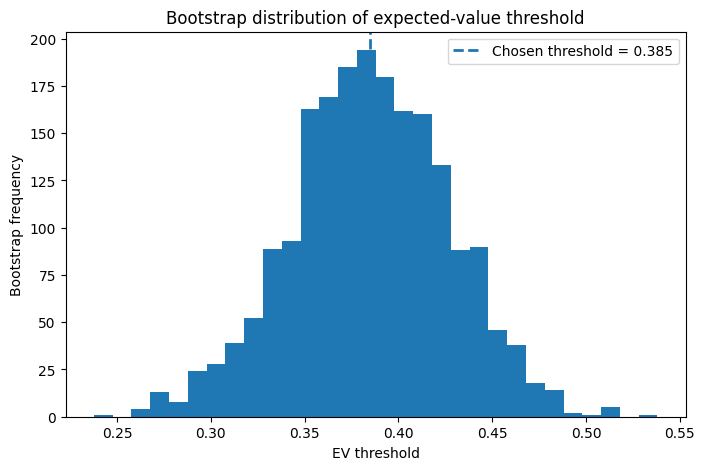

In [20]:
# =========================
# 19. OOF predictions for best config + EV threshold calculation
# =========================

HORIZON_DAYS_FOR_EVAL = get_horizon_days(best_data, default_horizon=5)

print("Using horizon days for evaluation:", HORIZON_DAYS_FOR_EVAL)

best_cpcv_model = make_vsn_classifier(BEST_MODEL_PARAMS)

best_fold_metrics_df, best_oof_raw_df = run_cpcv_for_model(
    model=best_cpcv_model,
    train_df=best_data["train_df"],
    feature_cols=best_data["feature_cols"],
    target_col=TARGET_COL,
    feature_processing_config=BEST_FEATURE_PROCESSING_CONFIG,
    n_blocks=CPCV_N_BLOCKS,
    n_test_blocks=CPCV_N_TEST_BLOCKS,
    embargo_size=best_data["num_days"],
    threshold=0.5,
)

best_oof_avg_df = average_oof_predictions(best_oof_raw_df)

# Attach primary_signal and approximate event returns to OOF predictions
train_events_for_returns = best_data["train_df"][
    [DATE_COL, INSTRUMENT_COL, "primary_signal", TARGET_COL]
].copy()

best_oof_eval_df = best_oof_avg_df.merge(
    train_events_for_returns,
    on=[DATE_COL, INSTRUMENT_COL],
    how="left",
)

best_oof_eval_df = attach_event_returns(
    event_df=best_oof_eval_df,
    features_df=features,
    ticker=TICKER,
    horizon_days=HORIZON_DAYS_FOR_EVAL,
)

threshold_summary, threshold_bootstrap_df = estimate_ev_threshold(
    train_eval_df=best_oof_eval_df,
    target_col="y_true",
    return_col="event_return",
    n_bootstrap=2000,
    random_state=RANDOM_STATE,
)

EV_THRESHOLD = threshold_summary["clipped_threshold"]

print("EV threshold summary:")
display(pd.DataFrame([threshold_summary]))

print("Chosen EV threshold:", EV_THRESHOLD)

plot_threshold_bootstrap(
    bootstrap_df=threshold_bootstrap_df,
    threshold=EV_THRESHOLD,
)

In [21]:
# =========================
# 20. Final fit on full training period + OOS test predictions
# =========================

final_train_df = best_data["train_df"].copy()
final_test_df = best_data["test_df"].copy()

y_final_train = final_train_df[TARGET_COL].astype(int)
y_oos = final_test_df[TARGET_COL].astype(int)

(
    X_final_train,
    X_oos,
    final_processed_feature_cols,
    final_processing_info,
) = apply_feature_processing_for_fold(
    fold_train=final_train_df,
    fold_test=final_test_df,
    feature_cols=best_data["feature_cols"],
    y_fold_train=y_final_train,
    feature_processing_config=BEST_FEATURE_PROCESSING_CONFIG,
)

final_vsn_model = make_vsn_classifier(BEST_MODEL_PARAMS)
final_vsn_model.fit(X_final_train, y_final_train)

print('Final VSN model trained.')
print('Processed feature count:', len(final_processed_feature_cols))
print('Epochs used:', final_vsn_model.n_epochs_)
print('Best validation loss:', final_vsn_model.best_val_loss_)

Final VSN model trained.
Processed feature count: 69
Epochs used: 35
Best validation loss: 0.27996131777763367


Top VSN permutation/MDA feature importances:


,feature,baseline_score,mean_permuted_score,std_permuted_score,importance,importance_method
0,vol_ratio_63_126d,0.621164,0.566138,0.016828,5.502646e-02,permutation_auc
1,ret_126d,0.621164,0.598307,0.006194,2.285714e-02,permutation_auc
2,ema20_vs_ema100,0.621164,0.600529,0.013191,2.063492e-02,permutation_auc
3,close_position_in_bar,0.621164,0.601481,0.022477,1.968254e-02,permutation_auc
4,atr_20d,0.621164,0.601799,0.016836,1.936508e-02,permutation_auc
5,open_interest_zscore_20d,0.621164,0.606772,0.008700,1.439153e-02,permutation_auc
6,hmm_market_calm_negative,0.621164,0.611746,0.002970,9.417989e-03,permutation_auc
7,vol_126d,0.621164,0.615556,0.004379,5.608466e-03,permutation_auc
8,hmm_prob_calm_positive,0.621164,0.615661,0.019215,5.502646e-03,permutation_auc
9,volume_to_open_interest,0.621164,0.616085,0.010870,5.079365e-03,permutation_auc


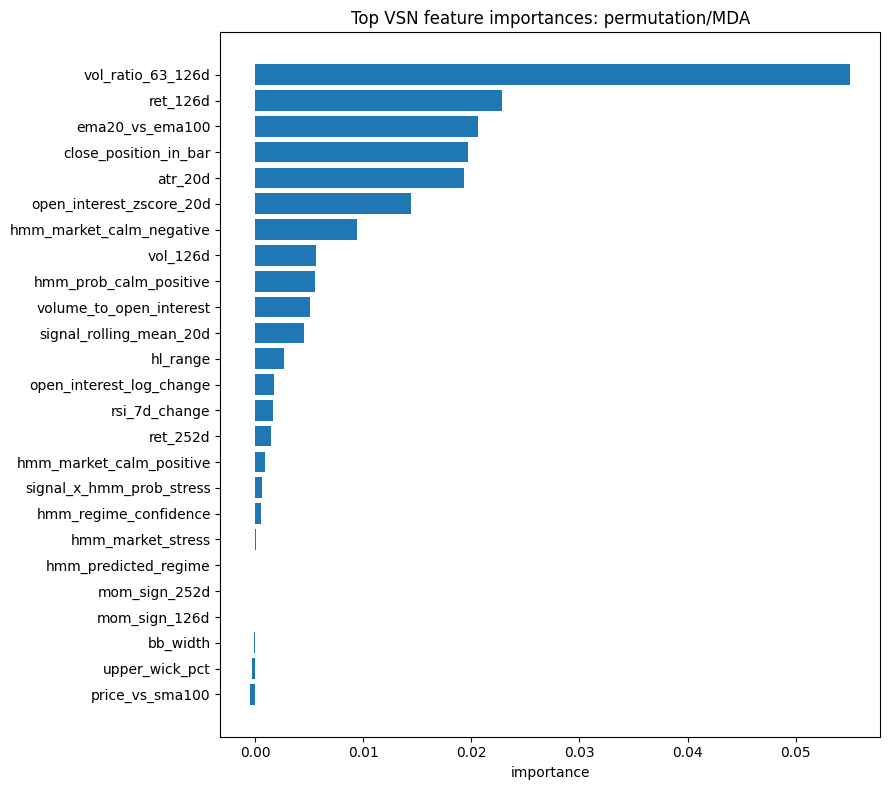

Top native VSN gate importances:


,feature,gate_importance
0,vol_ratio_63_126d,0.034346
1,mom_sign_126d,0.029924
2,lower_wick_pct,0.026254
3,macd_hist,0.025929
4,ema20_vs_ema100,0.025433
5,sma50_vs_sma100,0.024909
6,ret_63d,0.023016
7,vol_126d,0.022297
8,mom_sign_252d,0.019481
9,close_position_in_bar,0.019145


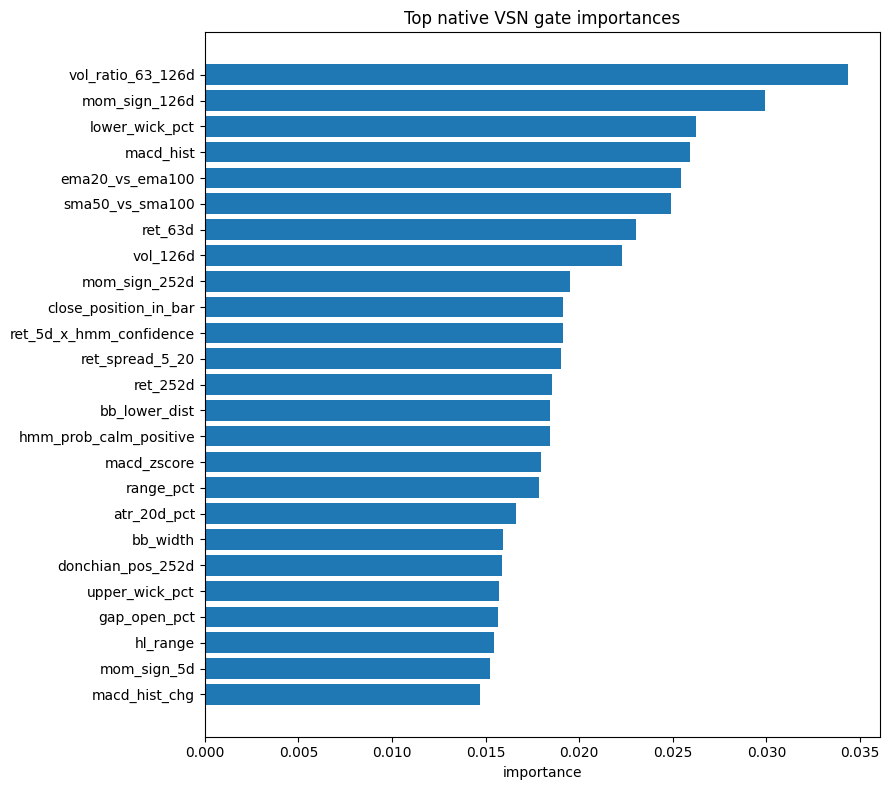

Top cluster-level feature importances:


,importance_group,cluster_importance,group_type,representative_model_features,n_model_features,cluster_id,cluster_n_features,cluster_features,dropped_cluster_features
0,vol_ratio_63_126d,5.502646e-02,single_feature,[vol_ratio_63_126d],1,NaN,1,[vol_ratio_63_126d],[]
1,ret_126d,2.285714e-02,single_feature,[ret_126d],1,NaN,1,[ret_126d],[]
2,"cluster_006: ema20_vs_ema100 (rep, n=4)",2.063492e-02,correlation_cluster,[ema20_vs_ema100],1,6.0,4,"[price_vs_sma200, sma50_vs_sma200, sma100_vs_s...","[price_vs_sma200, sma50_vs_sma200, sma100_vs_s..."
3,close_position_in_bar,1.968254e-02,single_feature,[close_position_in_bar],1,NaN,1,[close_position_in_bar],[]
4,"cluster_010: atr_20d (rep, n=4)",1.936508e-02,correlation_cluster,[atr_20d],1,10.0,4,"[atr_5d, atr_10d, atr_14d, atr_20d]","[atr_5d, atr_10d, atr_14d]"
5,"cluster_002: open_interest_zscore_20d (rep, n=3)",1.439153e-02,correlation_cluster,[open_interest_zscore_20d],1,2.0,3,"[open_interest, open_interest_zscore_20d, open...","[open_interest, open_interest_zscore_63d]"
6,hmm_market_calm_negative,9.417989e-03,single_feature,[hmm_market_calm_negative],1,NaN,1,[hmm_market_calm_negative],[]
7,vol_126d,5.608466e-03,single_feature,[vol_126d],1,NaN,1,[vol_126d],[]
8,hmm_prob_calm_positive,5.502646e-03,single_feature,[hmm_prob_calm_positive],1,NaN,1,[hmm_prob_calm_positive],[]
9,volume_to_open_interest,5.079365e-03,single_feature,[volume_to_open_interest],1,NaN,1,[volume_to_open_interest],[]


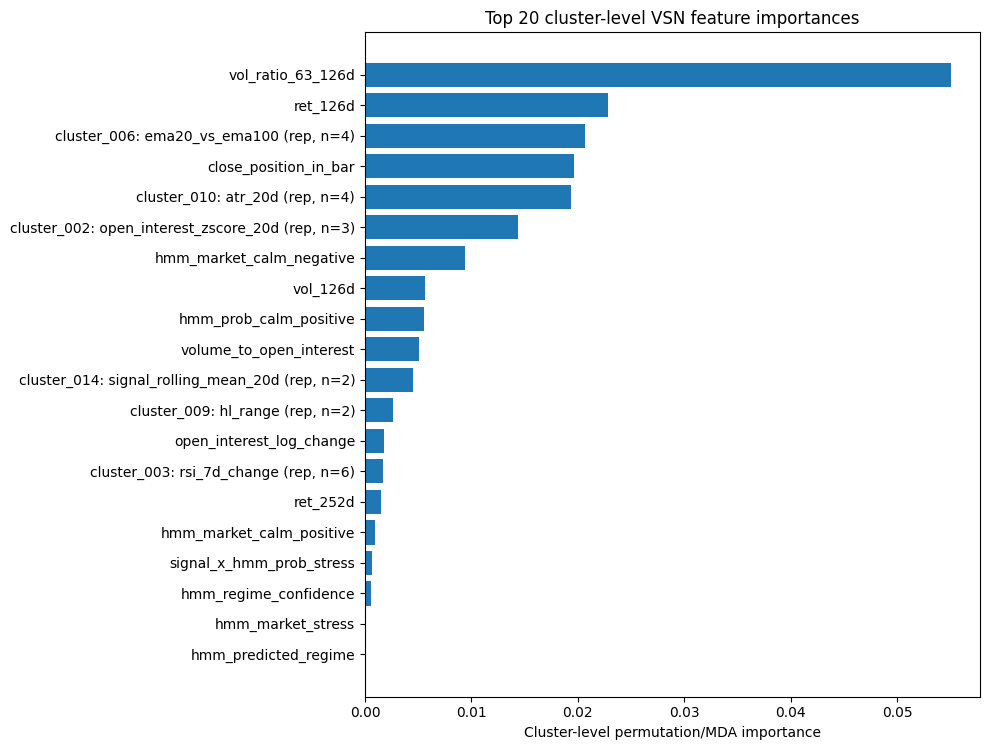

Correlation cluster summary from final training fit:


,cluster_id,n_features,representative_feature,dropped_features,cluster_features,max_abs_corr_in_cluster,mean_abs_corr_in_cluster,selection_method
0,1,4,low,"[open, high, close]","[open, high, low, close]",0.996607,0.993004,target_corr
1,2,3,open_interest_zscore_20d,"[open_interest, open_interest_zscore_63d]","[open_interest, open_interest_zscore_20d, open...",0.910598,0.878234,target_corr
2,3,6,rsi_7d_change,"[ret_1d, co_range, rsi_14d_change, rsi_21d_cha...","[ret_1d, co_range, rsi_7d_change, rsi_14d_chan...",0.997955,0.950824,target_corr
3,4,2,ret_5d_x_hmm_confidence,[ret_5d],"[ret_5d, ret_5d_x_hmm_confidence]",0.996557,0.996557,target_corr
4,5,33,ret_63d,"[ret_20d, price_vs_sma5, price_vs_sma10, price...","[ret_20d, ret_63d, price_vs_sma5, price_vs_sma...",1.000000,0.706301,target_corr
5,6,4,ema20_vs_ema100,"[price_vs_sma200, sma50_vs_sma200, sma100_vs_s...","[price_vs_sma200, sma50_vs_sma200, sma100_vs_s...",0.956819,0.897243,target_corr
6,7,18,atr_20d_pct,"[vol_5d, vol_10d, vol_20d, ewma_vol_5d, ewma_v...","[vol_5d, vol_10d, vol_20d, ewma_vol_5d, ewma_v...",0.999679,0.821262,target_corr
7,8,4,vol_63d,"[ewma_vol_63d, park_vol_63d, gk_vol_63d]","[vol_63d, ewma_vol_63d, park_vol_63d, gk_vol_63d]",0.990743,0.934260,target_corr
8,9,2,hl_range,[true_range],"[hl_range, true_range]",0.994550,0.994550,target_corr
9,10,4,atr_20d,"[atr_5d, atr_10d, atr_14d]","[atr_5d, atr_10d, atr_14d, atr_20d]",0.987962,0.939709,target_corr


High-correlation feature pairs from final training fit:


,feature_1,feature_2,abs_corr
0,stoch_k_14d,williams_r_14d,1.000000
1,price_vs_ema20,ema20_slope,1.000000
2,price_vs_ema50,ema50_slope,1.000000
3,hmm_prob_downside_or_weak,hmm_prob_positive_or_strong_upside,0.999926
4,vol_20d,vol_20d_for_interaction,0.999679
5,ret_20d,sma20_slope,0.999588
6,hmm_prob_high_or_extreme_vol,hmm_prob_low_or_normal_vol,0.999103
7,rsi_14d_change,rsi_21d_change,0.997955
8,low,close,0.996607
9,ret_5d,ret_5d_x_hmm_confidence,0.996557


In [22]:
# =========================
# 21. Feature importance and cluster-level feature importance
# =========================

# ---------------------------------------------------------
# 21A. Model-agnostic permutation / MDA feature importance
# ---------------------------------------------------------

def score_model_for_importance(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    scoring: str = "auc",
) -> float:
    """
    Returns score for permutation importance.

    Default is AUC. If only one class is present, falls back to F1 at 0.5.
    """
    y_true = pd.Series(y).astype(int)
    y_proba = get_positive_class_proba(model, X)

    if scoring == "auc" and y_true.nunique() == 2:
        return float(roc_auc_score(y_true, y_proba))

    y_pred = (y_proba >= 0.5).astype(int)
    return float(f1_score(y_true, y_pred, zero_division=0))


def compute_permutation_importance(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    n_repeats: int = 10,
    scoring: str = "auc",
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """
    Model-agnostic MDA/permutation importance.

    Importance = baseline score - score after shuffling one feature.
    """
    rng = np.random.default_rng(random_state)

    X_eval = X.copy()
    baseline_score = score_model_for_importance(model, X_eval, y, scoring=scoring)

    rows = []

    for col in X_eval.columns:
        permuted_scores = []

        for repeat in range(n_repeats):
            X_perm = X_eval.copy()
            X_perm[col] = rng.permutation(X_perm[col].to_numpy())
            permuted_scores.append(score_model_for_importance(model, X_perm, y, scoring=scoring))

        mean_permuted_score = float(np.mean(permuted_scores))
        std_permuted_score = float(np.std(permuted_scores, ddof=1)) if n_repeats > 1 else 0.0

        rows.append(
            {
                "feature": col,
                "baseline_score": baseline_score,
                "mean_permuted_score": mean_permuted_score,
                "std_permuted_score": std_permuted_score,
                "importance": baseline_score - mean_permuted_score,
                "importance_method": f"permutation_{scoring}",
            }
        )

    importance_df = (
        pd.DataFrame(rows)
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    return importance_df


def build_vsn_gate_importance_df(
    model: TorchVSNClassifier,
    X: pd.DataFrame,
) -> pd.DataFrame:
    """
    Native VSN variable importance: average softmax gate weight.
    """
    gate_weights = model.get_mean_selection_weights(X)

    return (
        pd.DataFrame(
            {
                "feature": list(X.columns),
                "gate_importance": gate_weights,
            }
        )
        .sort_values("gate_importance", ascending=False)
        .reset_index(drop=True)
    )


def plot_top_feature_importance(
    feature_importance_df: pd.DataFrame,
    importance_col: str = "importance",
    top_n: int = 25,
    title: str = "Top feature importances",
):
    """
    Plots feature importance.
    """
    plot_df = (
        feature_importance_df
        .head(top_n)
        .sort_values(importance_col, ascending=True)
    )

    plt.figure(figsize=(9, max(5, 0.32 * len(plot_df))))
    plt.barh(plot_df["feature"], plot_df[importance_col])
    plt.xlabel(importance_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# MDA / permutation importance is what you can cite as cluster-level model-agnostic importance.
feature_importance_df = compute_permutation_importance(
    model=final_vsn_model,
    X=X_oos,
    y=y_oos,
    n_repeats=10,
    scoring="auc",
    random_state=RANDOM_STATE,
)

print("Top VSN permutation/MDA feature importances:")
display(feature_importance_df.head(30))

plot_top_feature_importance(
    feature_importance_df=feature_importance_df,
    importance_col="importance",
    top_n=25,
    title="Top VSN feature importances: permutation/MDA",
)

# Native VSN gate weights are also useful as an interpretability sanity check.
vsn_gate_importance_df = build_vsn_gate_importance_df(
    model=final_vsn_model,
    X=X_final_train,
)

print("Top native VSN gate importances:")
display(vsn_gate_importance_df.head(30))

plot_top_feature_importance(
    feature_importance_df=vsn_gate_importance_df.rename(columns={"gate_importance": "importance"}),
    importance_col="importance",
    top_n=25,
    title="Top native VSN gate importances",
)


# ---------------------------------------------------------
# 21B. Cluster-level feature importance
# ---------------------------------------------------------

def build_cluster_importance_df(
    feature_importance_df: pd.DataFrame,
    processing_info: dict,
) -> pd.DataFrame:
    """
    Builds cluster-level feature importance.

    For corr_cluster:
        - correlated features were reduced to one representative feature
        - the representative feature's permutation/MDA importance is treated as the
          importance of that whole correlation cluster
        - unclustered features remain as single-feature groups

    For pca:
        - PCA components are shown as component-level groups

    For none:
        - each feature is its own group
    """
    method = processing_info.get("feature_method", "none")

    importance_df = feature_importance_df.copy()
    importance_df["importance_group"] = importance_df["feature"]
    importance_df["group_type"] = "single_feature"
    importance_df["cluster_id"] = np.nan
    importance_df["cluster_n_features"] = 1
    importance_df["cluster_features"] = importance_df["feature"].apply(lambda x: [x])
    importance_df["dropped_cluster_features"] = [[] for _ in range(len(importance_df))]

    if method == "corr_cluster":
        selector = processing_info.get("processor")

        if selector is not None and hasattr(selector, "cluster_summary_"):
            cluster_summary = selector.cluster_summary_.copy()

            if not cluster_summary.empty:
                rep_to_group = {}
                rep_to_cluster_id = {}
                rep_to_n_features = {}
                rep_to_cluster_features = {}
                rep_to_dropped_features = {}

                for row in cluster_summary.itertuples(index=False):
                    cluster_id = int(row.cluster_id)
                    representative = row.representative_feature
                    cluster_features = list(row.cluster_features)
                    dropped_features = list(row.dropped_features)

                    group_name = (
                        f"cluster_{cluster_id:03d}: "
                        f"{representative} "
                        f"(rep, n={len(cluster_features)})"
                    )

                    rep_to_group[representative] = group_name
                    rep_to_cluster_id[representative] = cluster_id
                    rep_to_n_features[representative] = len(cluster_features)
                    rep_to_cluster_features[representative] = cluster_features
                    rep_to_dropped_features[representative] = dropped_features

                is_cluster_rep = importance_df["feature"].isin(rep_to_group.keys())

                importance_df.loc[is_cluster_rep, "importance_group"] = (
                    importance_df.loc[is_cluster_rep, "feature"].map(rep_to_group)
                )
                importance_df.loc[is_cluster_rep, "group_type"] = "correlation_cluster"
                importance_df.loc[is_cluster_rep, "cluster_id"] = (
                    importance_df.loc[is_cluster_rep, "feature"].map(rep_to_cluster_id)
                )
                importance_df.loc[is_cluster_rep, "cluster_n_features"] = (
                    importance_df.loc[is_cluster_rep, "feature"].map(rep_to_n_features)
                )
                importance_df.loc[is_cluster_rep, "cluster_features"] = (
                    importance_df.loc[is_cluster_rep, "feature"].map(rep_to_cluster_features)
                )
                importance_df.loc[is_cluster_rep, "dropped_cluster_features"] = (
                    importance_df.loc[is_cluster_rep, "feature"].map(rep_to_dropped_features)
                )

    elif method == "pca":
        importance_df["group_type"] = "pca_component"

    cluster_importance_df = (
        importance_df
        .groupby("importance_group", as_index=False)
        .agg(
            cluster_importance=("importance", "sum"),
            group_type=("group_type", "first"),
            representative_model_features=("feature", lambda x: list(x)),
            n_model_features=("feature", "count"),
            cluster_id=("cluster_id", "first"),
            cluster_n_features=("cluster_n_features", "first"),
            cluster_features=("cluster_features", "first"),
            dropped_cluster_features=("dropped_cluster_features", "first"),
        )
        .sort_values("cluster_importance", ascending=False)
        .reset_index(drop=True)
    )

    return cluster_importance_df


def plot_cluster_importance(
    cluster_importance_df: pd.DataFrame,
    top_n: int = 20,
):
    """
    Plots cluster-level MDA/permutation importance.
    """
    plot_df = (
        cluster_importance_df
        .head(top_n)
        .sort_values("cluster_importance", ascending=True)
    )

    plt.figure(figsize=(10, max(5, 0.38 * len(plot_df))))
    plt.barh(plot_df["importance_group"], plot_df["cluster_importance"])
    plt.xlabel("Cluster-level permutation/MDA importance")
    plt.title(f"Top {top_n} cluster-level VSN feature importances")
    plt.tight_layout()
    plt.show()


cluster_importance_df = build_cluster_importance_df(
    feature_importance_df=feature_importance_df,
    processing_info=final_processing_info,
)

print("Top cluster-level feature importances:")
display(cluster_importance_df.head(30))

plot_cluster_importance(
    cluster_importance_df=cluster_importance_df,
    top_n=20,
)


if final_processing_info.get("feature_method") == "corr_cluster":
    selector = final_processing_info.get("processor")

    if selector is not None and hasattr(selector, "cluster_summary_"):
        print("Correlation cluster summary from final training fit:")
        display(selector.cluster_summary_.head(20))

        print("High-correlation feature pairs from final training fit:")
        display(selector.pair_summary_.head(20))


In [23]:
oos_proba = get_positive_class_proba(final_vsn_model, X_oos)

oos_predictions_df = final_test_df[
    [DATE_COL, INSTRUMENT_COL, "primary_signal", TARGET_COL]
].copy()

oos_predictions_df = oos_predictions_df.rename(columns={TARGET_COL: "y_true"})
oos_predictions_df["y_proba"] = oos_proba
oos_predictions_df["y_pred_0_5"] = (oos_predictions_df["y_proba"] >= 0.5).astype(int)
oos_predictions_df["y_pred_ev"] = (oos_predictions_df["y_proba"] >= EV_THRESHOLD).astype(int)

oos_metrics_05 = classification_metrics(
    y_true=oos_predictions_df["y_true"],
    y_proba=oos_predictions_df["y_proba"],
    threshold=0.5,
)

oos_metrics_ev = classification_metrics(
    y_true=oos_predictions_df["y_true"],
    y_proba=oos_predictions_df["y_proba"],
    threshold=EV_THRESHOLD,
)

print("OOS metrics at threshold 0.5:")
display(pd.DataFrame([oos_metrics_05]))

print(f"OOS metrics at EV threshold {EV_THRESHOLD:.4f}:")
display(pd.DataFrame([oos_metrics_ev]))

display(oos_predictions_df.head())

OOS metrics at threshold 0.5:


,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,0.75641,0.814286,0.904762,0.857143,0.621164,2,13,6,57


OOS metrics at EV threshold 0.3850:


,accuracy,precision,recall,f1,auc,tn,fp,fn,tp
0,0.807692,0.815789,0.984127,0.892086,0.621164,1,14,1,62


,date,instrument,primary_signal,y_true,y_proba,y_pred_0_5,y_pred_ev
333,2022-01-03,cl1s,1,1,0.889757,1,1
334,2022-01-04,cl1s,1,1,0.888865,1,1
335,2022-01-05,cl1s,1,1,0.902510,1,1
336,2022-01-06,cl1s,1,1,0.870119,1,1
337,2022-01-07,cl1s,1,1,0.914122,1,1


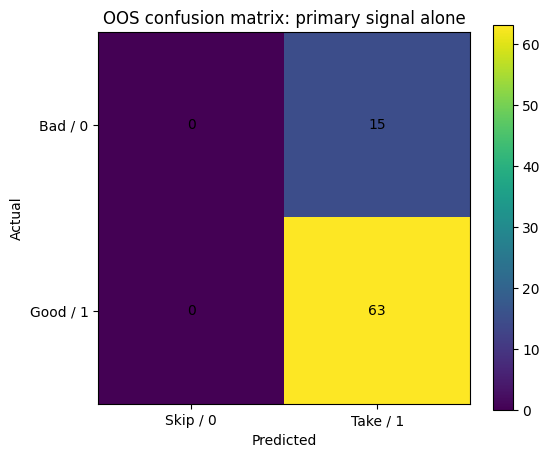

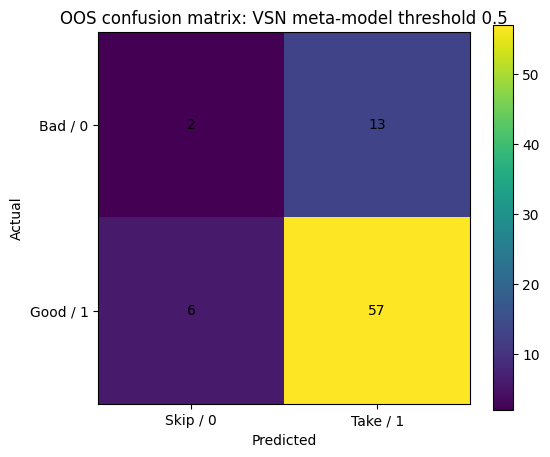

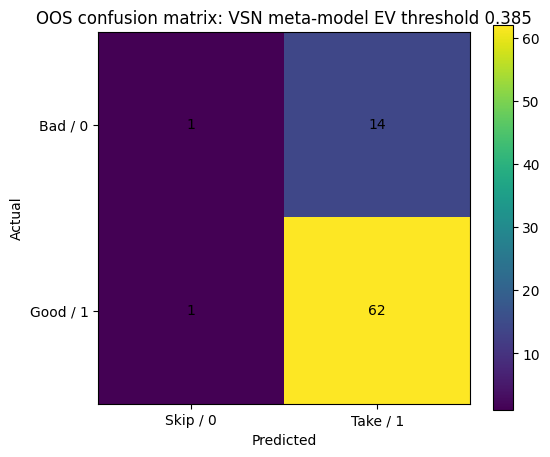

In [24]:
# =========================
# 21. Confusion matrix visualisations
# =========================

def plot_confusion_matrix_from_labels(
    y_true,
    y_pred,
    title: str,
):
    """
    Plots a simple confusion matrix.
    Rows = actual labels.
    Columns = predicted labels.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Skip / 0", "Take / 1"])
    plt.yticks([0, 1], ["Bad / 0", "Good / 1"])
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.show()


# Primary baseline: always take every primary signal
# Since train_on_nonzero_signals_only=True, every row here is a primary trade candidate.
oos_predictions_df["primary_baseline_pred"] = 1

plot_confusion_matrix_from_labels(
    y_true=oos_predictions_df["y_true"],
    y_pred=oos_predictions_df["primary_baseline_pred"],
    title="OOS confusion matrix: primary signal alone",
)

plot_confusion_matrix_from_labels(
    y_true=oos_predictions_df["y_true"],
    y_pred=oos_predictions_df["y_pred_0_5"],
    title="OOS confusion matrix: VSN meta-model threshold 0.5",
)

plot_confusion_matrix_from_labels(
    y_true=oos_predictions_df["y_true"],
    y_pred=oos_predictions_df["y_pred_ev"],
    title=f"OOS confusion matrix: VSN meta-model EV threshold {EV_THRESHOLD:.3f}",
)

In [25]:
# =========================
# 24. Strategy returns, Sharpe, and NAV helpers
# =========================

def annualised_sharpe(
    returns: pd.Series,
    periods_per_year: float = 252,
) -> float:
    """
    Annualised Sharpe ratio.

    For horizon returns, use periods_per_year = 252 / horizon_days.
    """
    r = pd.Series(returns).replace([np.inf, -np.inf], np.nan).dropna()

    if len(r) < 2:
        return np.nan

    std = r.std(ddof=1)

    if std == 0 or pd.isna(std):
        return np.nan

    return float(np.sqrt(periods_per_year) * r.mean() / std)


def max_drawdown(nav: pd.Series) -> float:
    """
    Maximum drawdown from a NAV series.
    """
    nav = pd.Series(nav).dropna()

    if len(nav) == 0:
        return np.nan

    running_max = nav.cummax()
    drawdown = nav / running_max - 1.0

    return float(drawdown.min())


def build_strategy_analysis(
    predictions_df: pd.DataFrame,
    features_df: pd.DataFrame,
    ticker: str,
    horizon_days: int,
    threshold: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compares:
        1. Primary alone: take every primary signal
        2. Primary + VSN meta-model: take only when y_proba >= threshold

    Returns:
        strategy_df
        summary_df
    """
    strategy_df = attach_event_returns(
        event_df=predictions_df,
        features_df=features_df,
        ticker=ticker,
        horizon_days=horizon_days,
    )

    strategy_df = strategy_df.dropna(subset=["event_return"]).copy()
    strategy_df = strategy_df.sort_values(DATE_COL).reset_index(drop=True)

    strategy_df["meta_take_trade"] = (strategy_df["y_proba"] >= threshold).astype(int)

    # Primary alone takes every signal.
    strategy_df["primary_return"] = strategy_df["event_return"]

    # Meta-model gates the primary signal: below threshold, return is zero.
    strategy_df["meta_return"] = strategy_df["meta_take_trade"] * strategy_df["event_return"]

    strategy_df["primary_nav"] = (1.0 + strategy_df["primary_return"]).cumprod()
    strategy_df["meta_nav"] = (1.0 + strategy_df["meta_return"]).cumprod()

    periods_per_year = 252 / horizon_days

    summary_df = pd.DataFrame(
        [
            {
                "strategy": "Primary alone",
                "n_trades_taken": int(len(strategy_df)),
                "trade_rate": 1.0,
                "mean_event_return": strategy_df["primary_return"].mean(),
                "total_profit_pct": strategy_df["primary_nav"].iloc[-1] - 1.0,
                "annualised_sharpe": annualised_sharpe(
                    strategy_df["primary_return"],
                    periods_per_year=periods_per_year,
                ),
                "max_drawdown": max_drawdown(strategy_df["primary_nav"]),
            },
            {
                "strategy": "Primary + VSN meta filter",
                "n_trades_taken": int(strategy_df["meta_take_trade"].sum()),
                "trade_rate": float(strategy_df["meta_take_trade"].mean()),
                "mean_event_return": strategy_df["meta_return"].mean(),
                "total_profit_pct": strategy_df["meta_nav"].iloc[-1] - 1.0,
                "annualised_sharpe": annualised_sharpe(
                    strategy_df["meta_return"],
                    periods_per_year=periods_per_year,
                ),
                "max_drawdown": max_drawdown(strategy_df["meta_nav"]),
            },
        ]
    )

    return strategy_df, summary_df


def plot_nav_comparison(strategy_df: pd.DataFrame, title: str):
    """
    Plots cumulative NAV before and after meta-model filtering.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(strategy_df[DATE_COL], strategy_df["primary_nav"], label="Primary alone")
    plt.plot(strategy_df[DATE_COL], strategy_df["meta_nav"], label="Primary + VSN meta filter")
    plt.xlabel("Date")
    plt.ylabel("NAV")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

OOS strategy comparison:


,strategy,n_trades_taken,trade_rate,mean_event_return,total_profit_pct,annualised_sharpe,max_drawdown
0,Primary alone,78,1.000000,0.064586,102.797663,3.820510,-0.509453
1,Primary + VSN meta filter,76,0.974359,0.064576,102.743774,3.821253,-0.509453


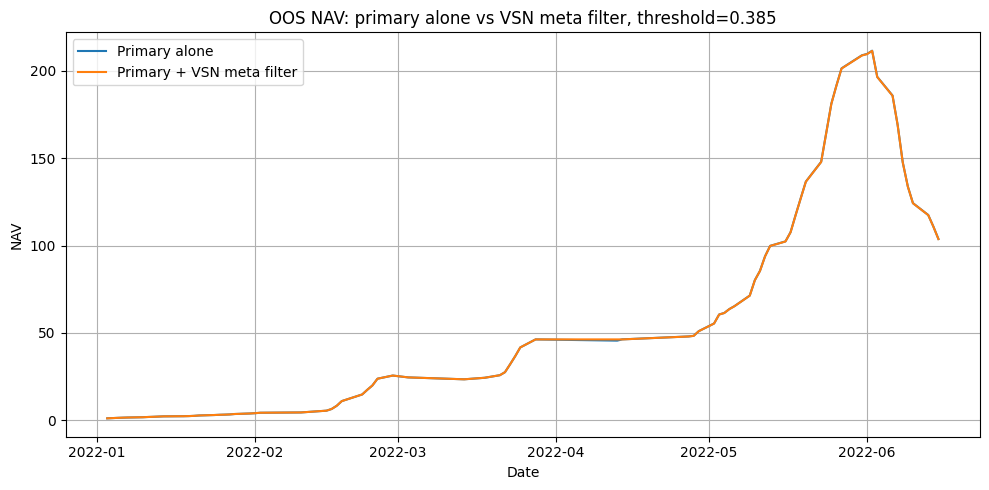

,date,instrument,primary_signal,y_true,y_proba,y_pred_0_5,y_pred_ev,primary_baseline_pred,entry_close_eval,exit_close_eval,raw_horizon_return,event_return,meta_take_trade,primary_return,meta_return,primary_nav,meta_nav
0,2022-01-03,cl1s,1,1,0.889757,1,1,1,22.680904,25.444369,0.121841,0.121841,1,0.121841,0.121841,1.121841,1.121841
1,2022-01-04,cl1s,1,1,0.888865,1,1,1,22.952193,25.735316,0.121257,0.121257,1,0.121257,0.121257,1.257873,1.257873
2,2022-01-05,cl1s,1,1,0.902510,1,1,1,23.208575,25.660330,0.105640,0.105640,1,0.105640,0.105640,1.390754,1.390754
3,2022-01-06,cl1s,1,1,0.870119,1,1,1,23.688547,25.537352,0.078046,0.078046,1,0.078046,0.078046,1.499297,1.499297
4,2022-01-07,cl1s,1,1,0.914122,1,1,1,23.521600,24.988452,0.062362,0.062362,1,0.062362,0.062362,1.592797,1.592797


In [26]:
# =========================
# 25. OOS Sharpe and profit before/after meta-model
# =========================

oos_strategy_df, oos_strategy_summary_df = build_strategy_analysis(
    predictions_df=oos_predictions_df,
    features_df=features,
    ticker=TICKER,
    horizon_days=HORIZON_DAYS_FOR_EVAL,
    threshold=EV_THRESHOLD,
)

print("OOS strategy comparison:")
display(oos_strategy_summary_df)

plot_nav_comparison(
    strategy_df=oos_strategy_df,
    title=f"OOS NAV: primary alone vs VSN meta filter, threshold={EV_THRESHOLD:.3f}",
)

display(oos_strategy_df.head())

In [27]:
# =========================
# 26. Save OOS predictions and strategy outputs
# =========================

MODEL_OUTPUT_DIR = Path("../../data/model_outputs/neural_network")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OOS_PREDICTIONS_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_oos_predictions.csv"
SUBMISSION_PREDICTIONS_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_metamodel_predictions_submission_format.csv"
OOS_STRATEGY_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_oos_strategy_returns.csv"
OOS_STRATEGY_SUMMARY_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_oos_strategy_summary.csv"
FEATURE_IMPORTANCE_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_permutation_feature_importance.csv"
VSN_GATE_IMPORTANCE_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_gate_importance.csv"
CLUSTER_IMPORTANCE_PATH = MODEL_OUTPUT_DIR / f"{TICKER}_vsn_cluster_importance.csv"

oos_predictions_df.to_csv(OOS_PREDICTIONS_PATH, index=False)

# Required coursework-style output: one row per date/instrument/prediction.
submission_predictions_df = (
    oos_predictions_df[[DATE_COL, INSTRUMENT_COL, "y_proba"]]
    .rename(columns={"y_proba": "prediction"})
    .copy()
)
submission_predictions_df["prediction"] = submission_predictions_df["prediction"].clip(0.0, 1.0)

submission_predictions_df.to_csv(SUBMISSION_PREDICTIONS_PATH, index=False)

oos_strategy_df.to_csv(OOS_STRATEGY_PATH, index=False)
oos_strategy_summary_df.to_csv(OOS_STRATEGY_SUMMARY_PATH, index=False)
feature_importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
vsn_gate_importance_df.to_csv(VSN_GATE_IMPORTANCE_PATH, index=False)
cluster_importance_df.to_csv(CLUSTER_IMPORTANCE_PATH, index=False)

print("Saved:")
print(OOS_PREDICTIONS_PATH)
print(SUBMISSION_PREDICTIONS_PATH)
print(OOS_STRATEGY_PATH)
print(OOS_STRATEGY_SUMMARY_PATH)
print(FEATURE_IMPORTANCE_PATH)
print(VSN_GATE_IMPORTANCE_PATH)
print(CLUSTER_IMPORTANCE_PATH)

print("\nSubmission-format predictions preview:")
display(submission_predictions_df.head())


Saved:
../../data/model_outputs/neural_network/cl1s_vsn_oos_predictions.csv
../../data/model_outputs/neural_network/cl1s_vsn_metamodel_predictions_submission_format.csv
../../data/model_outputs/neural_network/cl1s_vsn_oos_strategy_returns.csv
../../data/model_outputs/neural_network/cl1s_vsn_oos_strategy_summary.csv
../../data/model_outputs/neural_network/cl1s_vsn_permutation_feature_importance.csv
../../data/model_outputs/neural_network/cl1s_vsn_gate_importance.csv
../../data/model_outputs/neural_network/cl1s_vsn_cluster_importance.csv

Submission-format predictions preview:


,date,instrument,prediction
333,2022-01-03,cl1s,0.889757
334,2022-01-04,cl1s,0.888865
335,2022-01-05,cl1s,0.902510
336,2022-01-06,cl1s,0.870119
337,2022-01-07,cl1s,0.914122
